# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 65     |  |
| :-------------|:-------------|
| Thijmen Haverkorn van Rijsewijk | 6500897 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Thijmen']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| afronden van de kalibratie | 12:00 |
| uitvoeren van de laatste testmeting | 13:00 |

## Opdracht 2: Import libs.

In [2]:
!pip install pandas

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [65]
<img src="opstelling calibratie.jpg" width="400">

In deze stap hebben we de ultrasone sensor gekalibreerd om de pulsduur (in microseconden) om te zetten naar een afstand (in centimeters). We hebben hiervoor zowel directe metingen gedaan als een meting met een reflecterend oppervlak om de totale afgelegde afstand ($R$) te bepalen.


In [ ]:
# oude calibratie data

import numpy as np

afstanden = np.array([15, 25, 40, 60]) 
tijden = np.array([460, 780, 1210, 1780]) 

alpha_f, beta_f = np.polyfit(tijden, afstanden, 1)

print(f"Gevonden alpha: {alpha_f:.5f}")
print(f"Gevonden beta: {beta_f:.5f}")

Deze waardes komen niet goed uit bij de sanity check. De onauwkeurigheid in mijn meetinen waren te groot daarom heb ik een paar dingen verandert;
- Ik maak gebruik van een rooster, waardoor ik de locatie van mijn transmittor, reciever en het blikje nauwkeuiriger kan bepalen.
- Ik maak gebruik van een karton rechthoekje die ik aan het eerder gebruikte blikje heb geplakt. Hierdoor is de reflectatie van het geluid minder verspreid. 

Hieronder zie je een foto van de nieuwe opstelling; 

<img src="opstelling_betahhh.jpg" width="400">

,Positie Karton (cm),Gemeten Tijd (us),Afgelegde Weg D (cm)
0,20,1290,41.231056
1,30,1920,60.827625
2,40,2450,80.622577
3,50,2970,100.498756
4,60,3600,120.415946
5,70,4280,140.356688
6,80,4760,160.312195



Berekende Alpha: 0.03411
Berekende Beta:  -3.03305


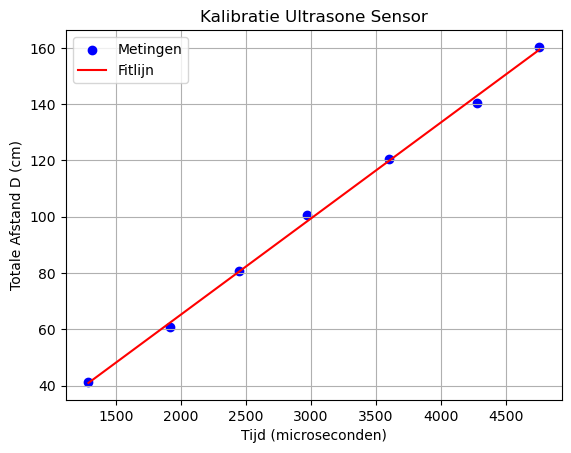

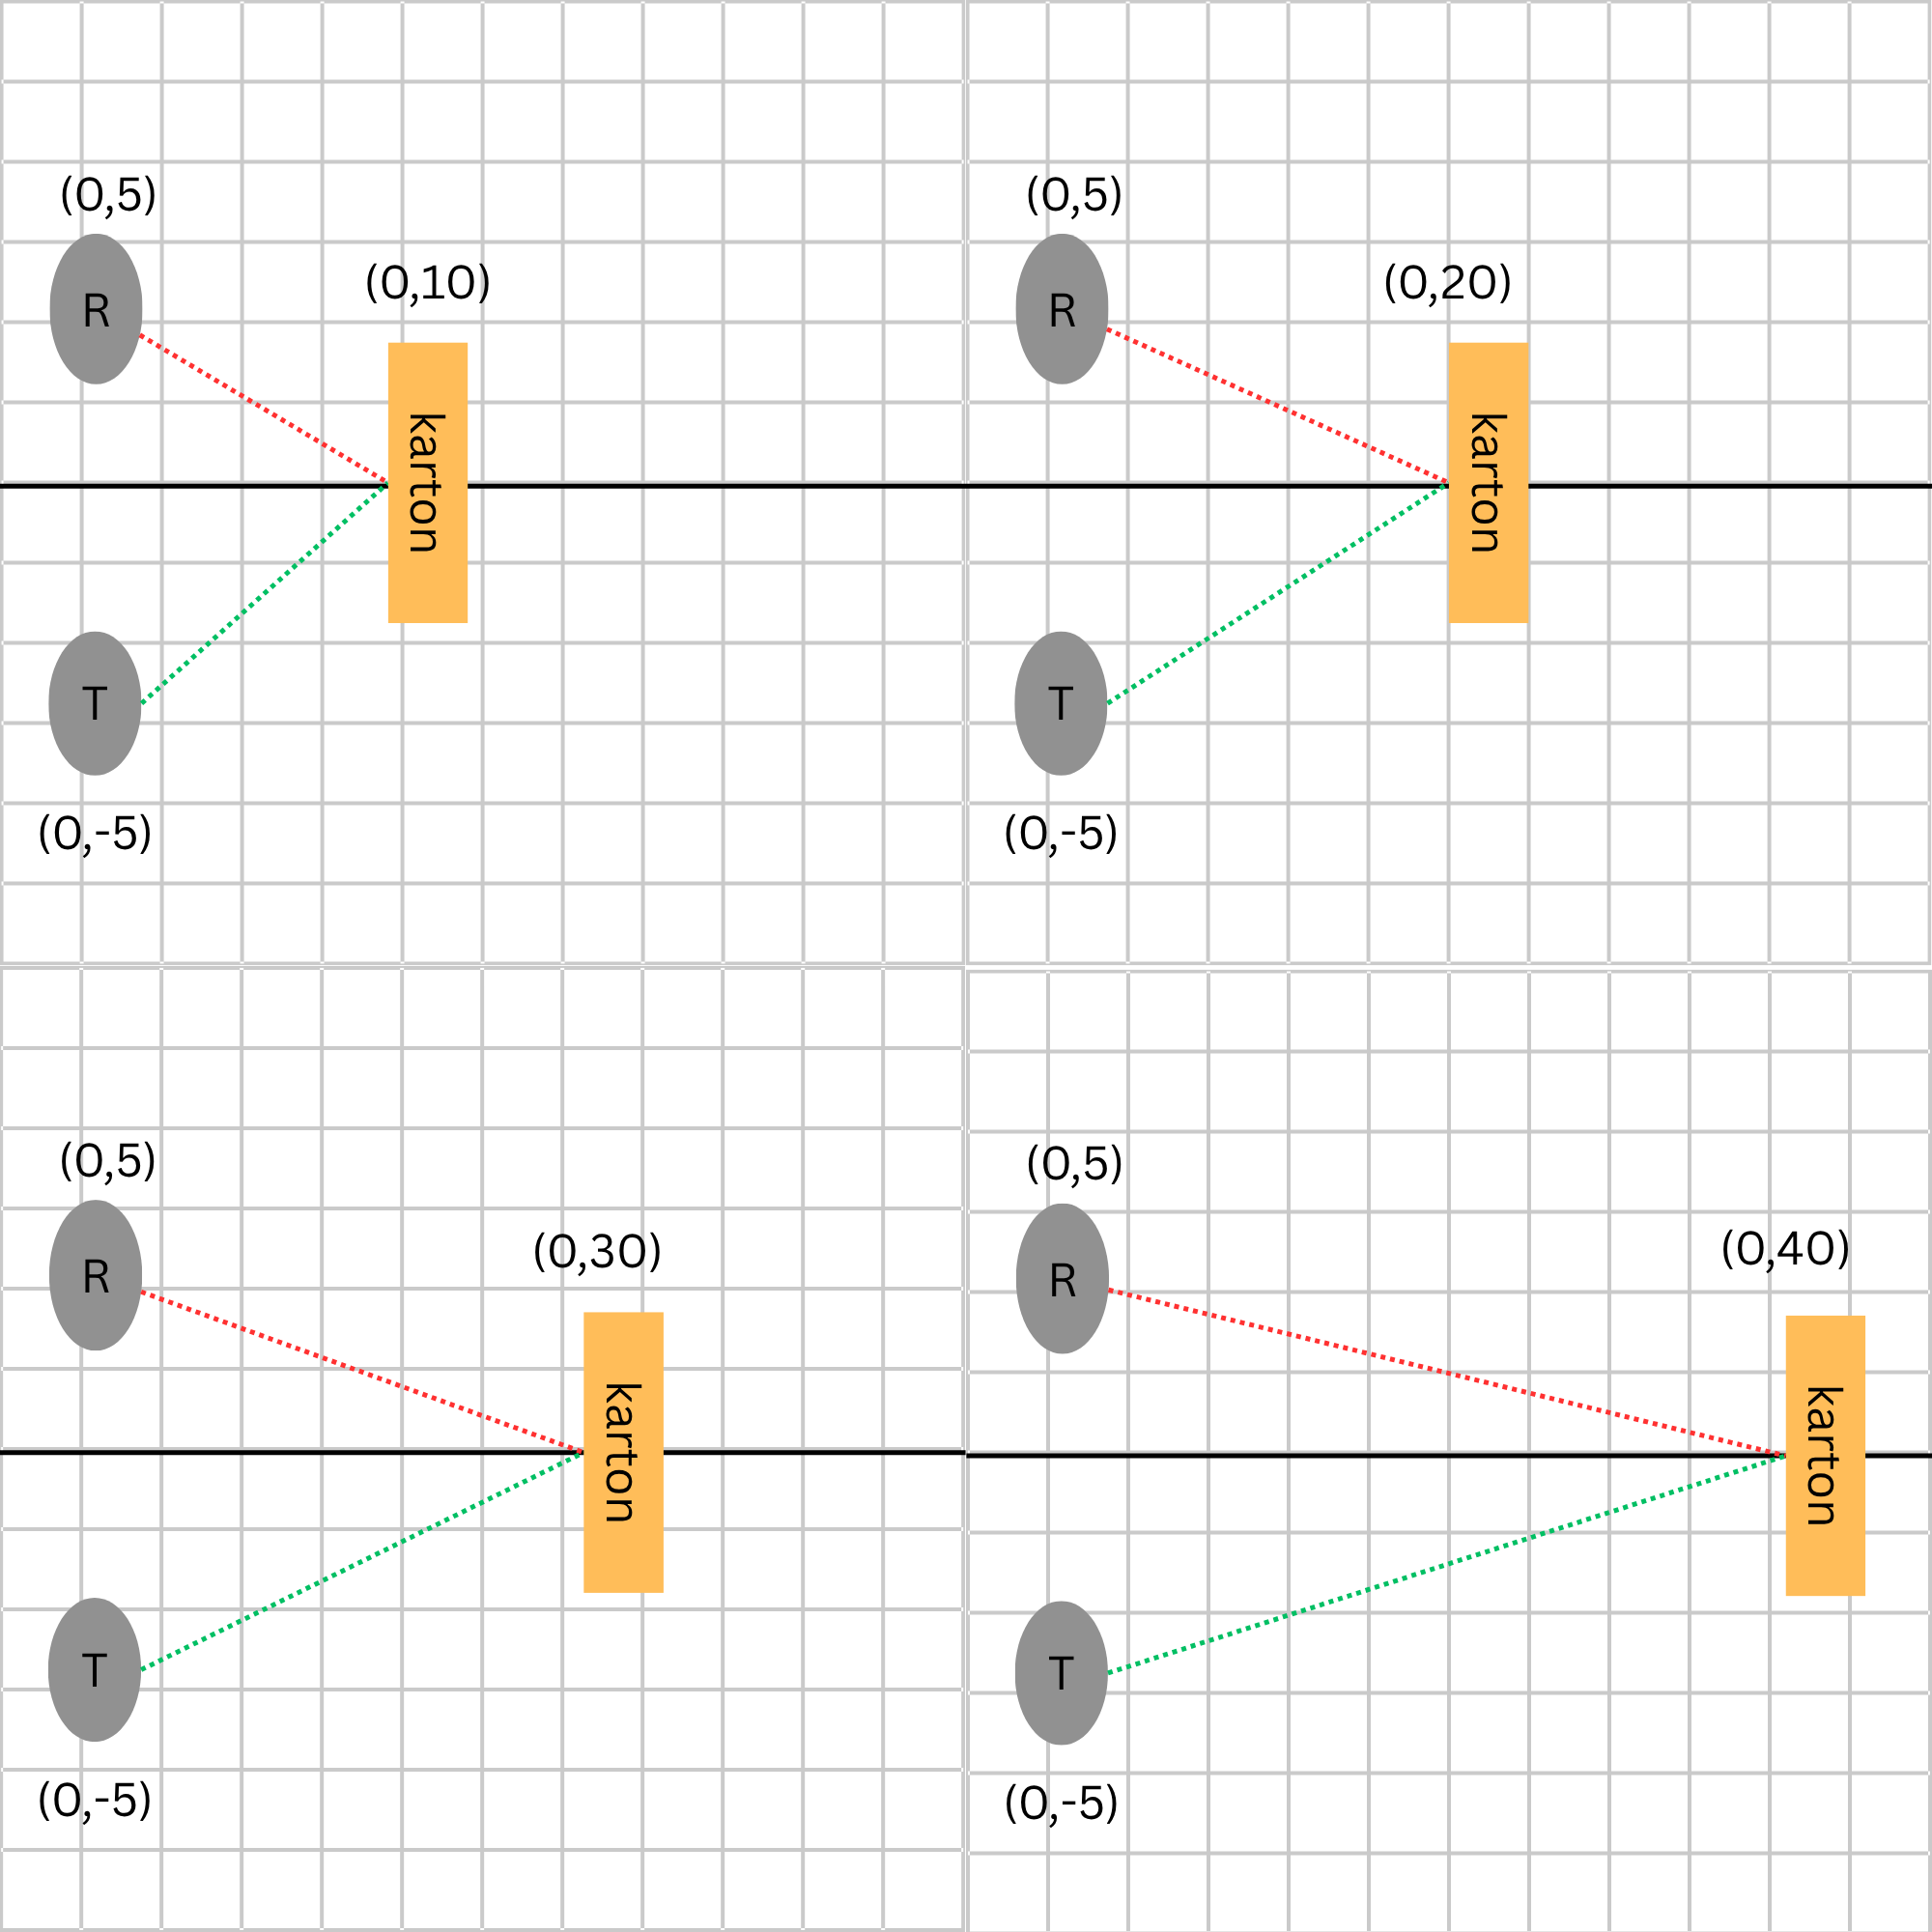

In [ ]:
# calibratie 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d = 5 
pos_karton = np.array([20, 30, 40, 50, 60, 70, 80]) 
SerialMonitor = np.array([1290, 1920, 2450, 2970, 3600, 4280, 4760]) # microseconden / serial monitor


D = 2 * np.sqrt(d**2 + pos_karton**2)

df_kalibratie = pd.DataFrame({
    'Positie Karton (cm)': pos_karton,
    'Gemeten Tijd (us)': SerialMonitor,
    'Afgelegde Weg D (cm)': D
})

display(df_kalibratie)

poly = np.polyfit(SerialMonitor, D, 1)
alpha = poly[0]
beta = poly[1]

print(f"\nBerekende Alpha: {alpha:.5f}")
print(f"Berekende Beta:  {beta:.5f}")

plt.scatter(SerialMonitor, D, color='blue', label='Metingen')
plt.plot(SerialMonitor, alpha * SerialMonitor + beta, color='red', label='Fitlijn')
plt.xlabel('Tijd (microseconden)')
plt.ylabel('Totale Afstand D (cm)')
plt.title('Kalibratie Ultrasone Sensor')
plt.legend()
plt.grid(True)
plt.show()

from IPython.display import Image, display

display(Image(filename="calibratie.png"))

,Positie Karton (cm),Gemeten Tijd (us),Afgelegde Weg D (cm)
0,20,1252,41.231056
1,30,1820,60.827625
2,40,2382,80.622577
3,50,2915,100.498756
4,60,3483,120.415946
5,70,4057,140.356688
6,80,4650,160.312195



Berekende Alpha: 0.03526
Berekende Beta:  -2.94801


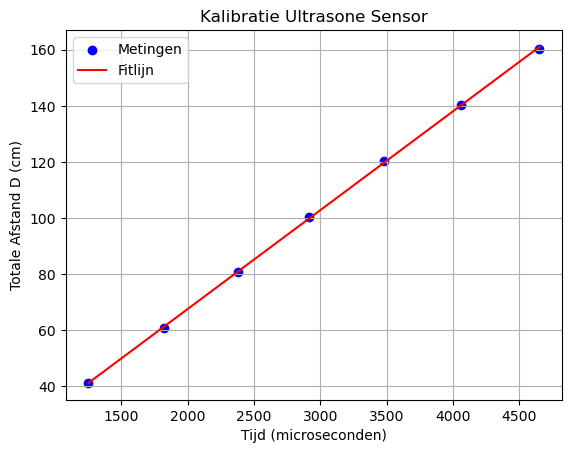

In [22]:
# calibratie 3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d = 5 
pos_karton = np.array([20, 30, 40, 50, 60, 70, 80]) 
SerialMonitor = np.array([1252, 1820, 2382, 2915, 3483, 4057, 4650]) # microseconden / serial monitor


D = 2 * np.sqrt(d**2 + pos_karton**2)

df_kalibratie = pd.DataFrame({
    'Positie Karton (cm)': pos_karton,
    'Gemeten Tijd (us)': SerialMonitor,
    'Afgelegde Weg D (cm)': D
})

display(df_kalibratie)

poly = np.polyfit(SerialMonitor, D, 1)
alpha = poly[0]
beta = poly[1]

print(f"\nBerekende Alpha: {alpha:.5f}")
print(f"Berekende Beta:  {beta:.5f}")

plt.scatter(SerialMonitor, D, color='blue', label='Metingen')
plt.plot(SerialMonitor, alpha * SerialMonitor + beta, color='red', label='Fitlijn')
plt.xlabel('Tijd (microseconden)')
plt.ylabel('Totale Afstand D (cm)')
plt.title('Kalibratie Ultrasone Sensor')
plt.legend()
plt.grid(True)
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  -5   0   5   98.5
1   0  -5   0  10  100.2
2   0  -5   0  15  102.0
3   0  -5   0  20  108.0


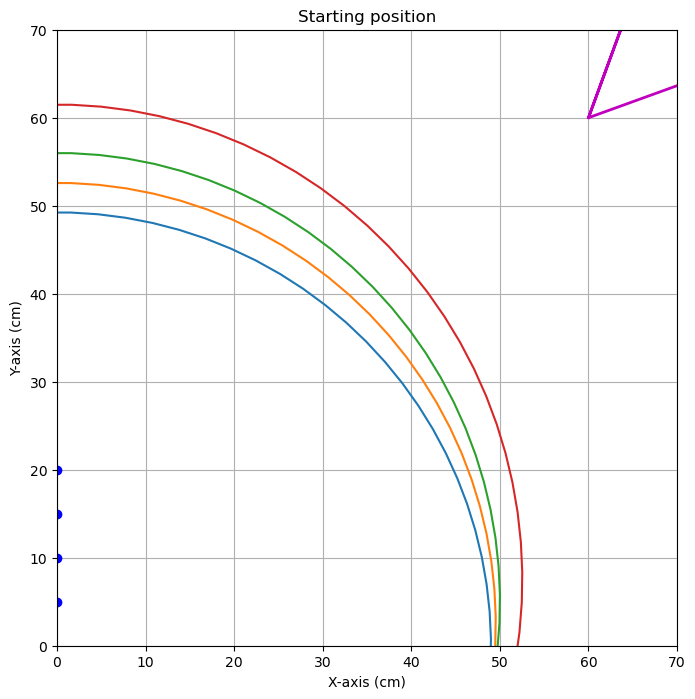


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=70.333


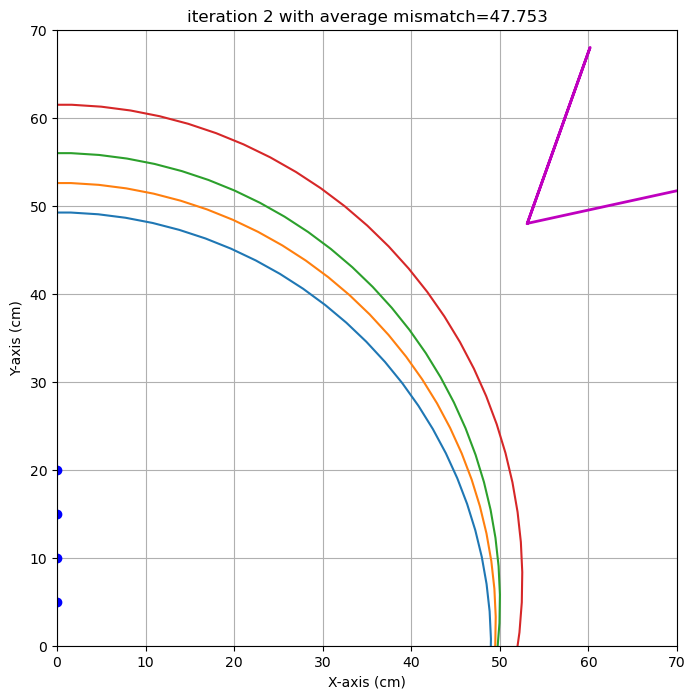

end iteration 2 with average mismatch=47.753


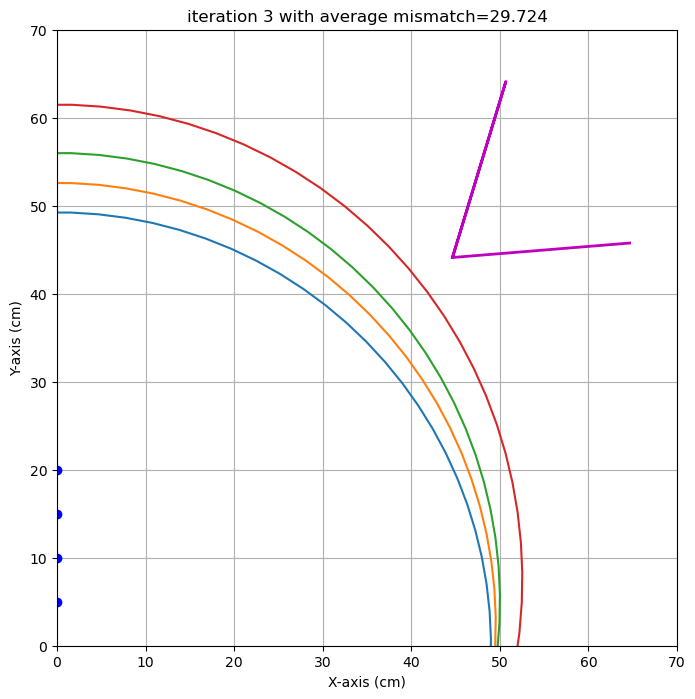

end iteration 3 with average mismatch=29.724


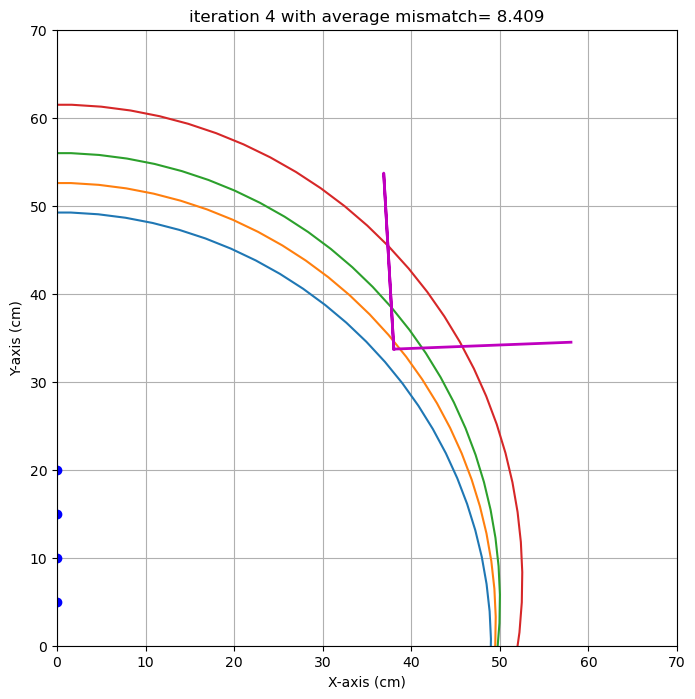

end iteration 4 with average mismatch= 8.409


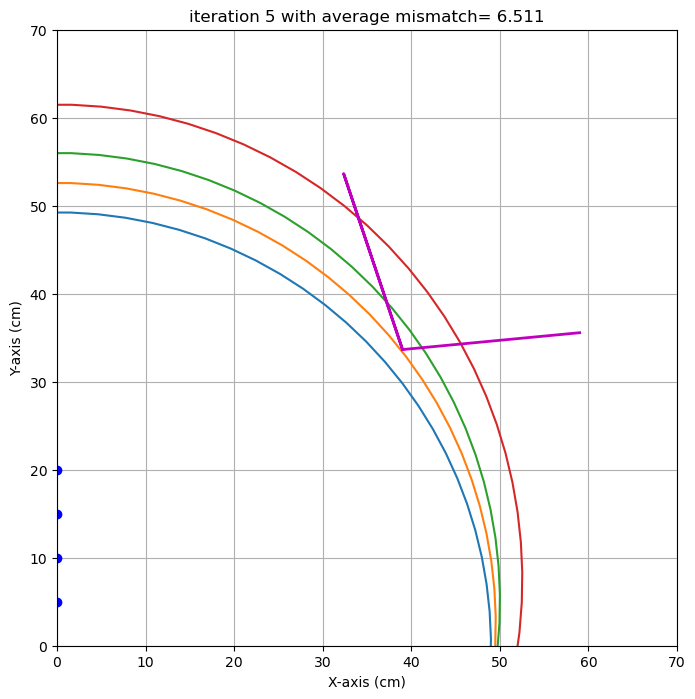

end iteration 5 with average mismatch= 6.511


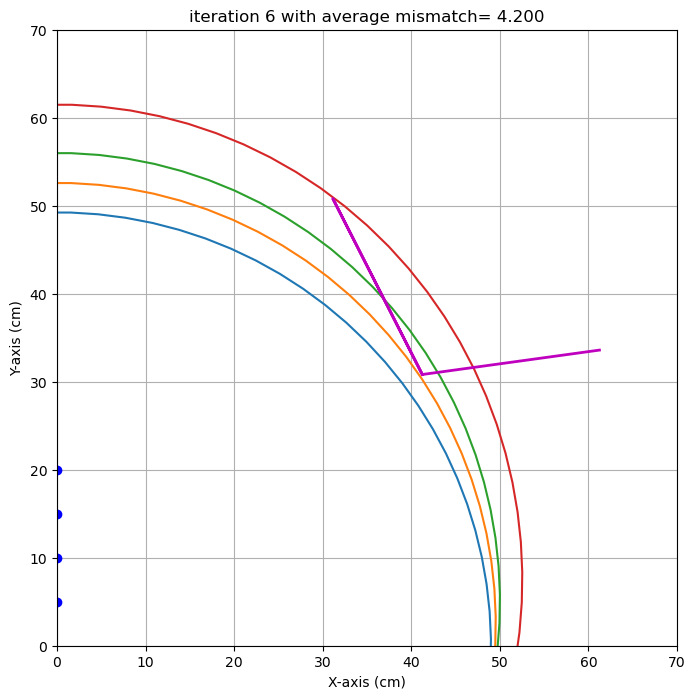

end iteration 6 with average mismatch= 4.200
end iteration 7 with average mismatch= 4.157
end iteration 8 with average mismatch= 4.092
end iteration 9 with average mismatch= 3.908


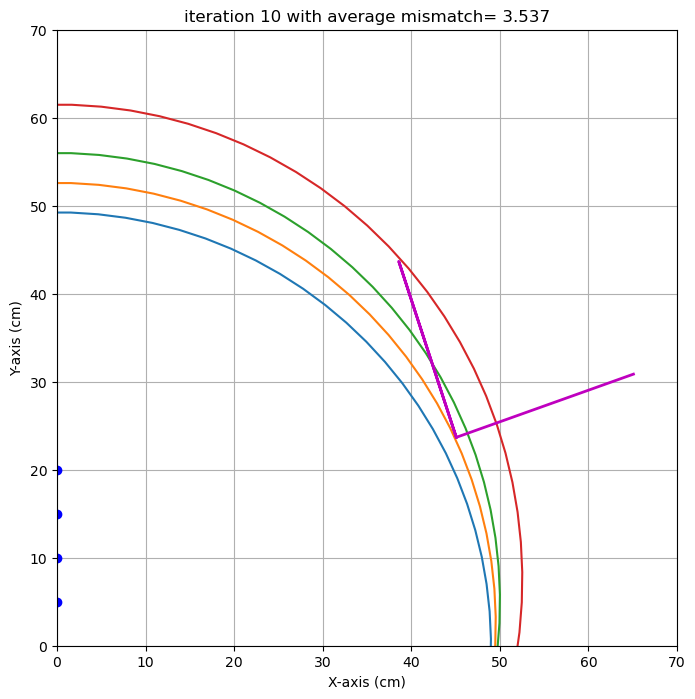

end iteration 10 with average mismatch= 3.537
end iteration 11 with average mismatch= 3.310
end iteration 12 with average mismatch= 3.059


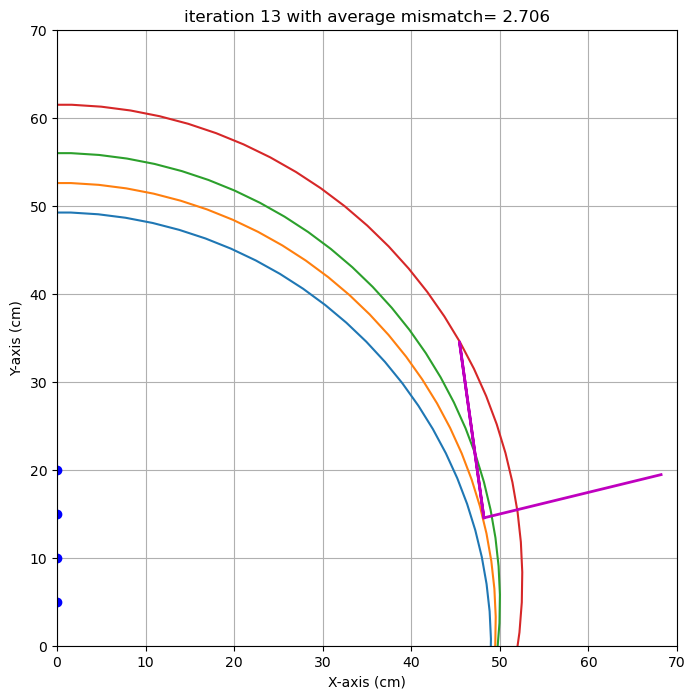

end iteration 13 with average mismatch= 2.706


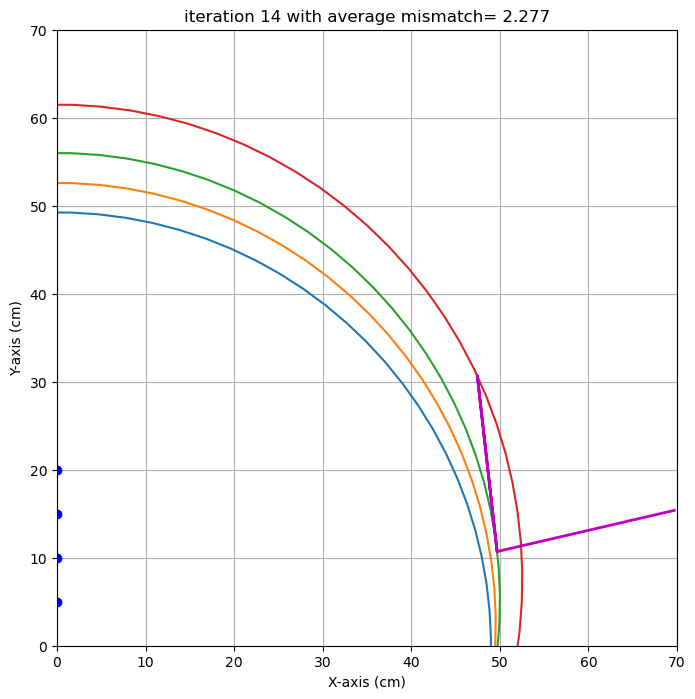

end iteration 14 with average mismatch= 2.277
end iteration 15 with average mismatch= 2.174
end iteration 16 with average mismatch= 2.156


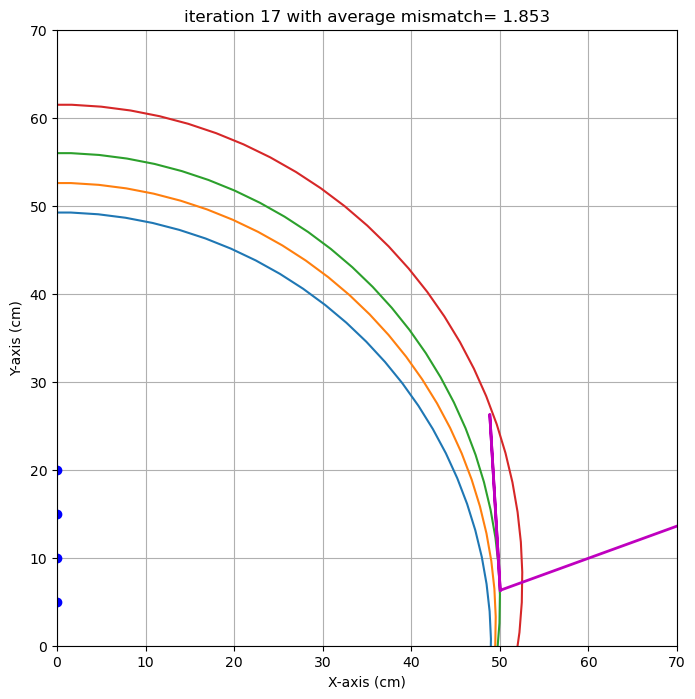

end iteration 17 with average mismatch= 1.853


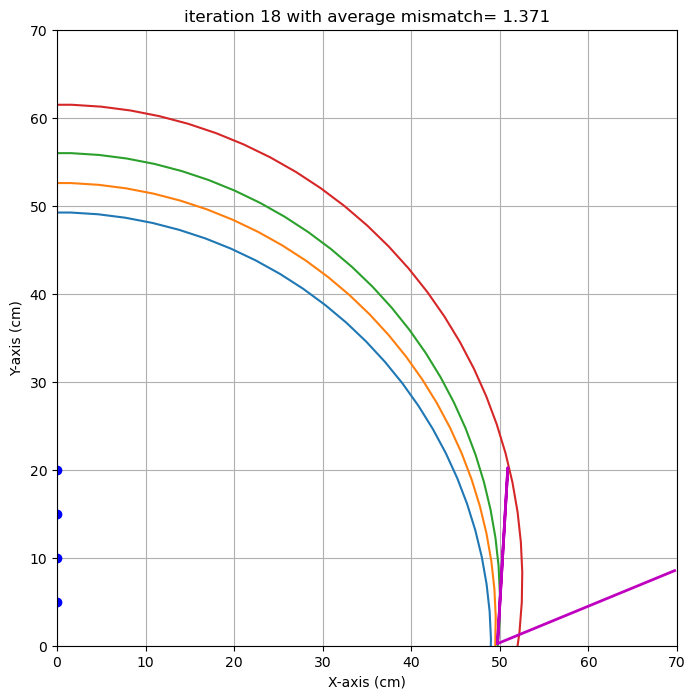

end iteration 18 with average mismatch= 1.371


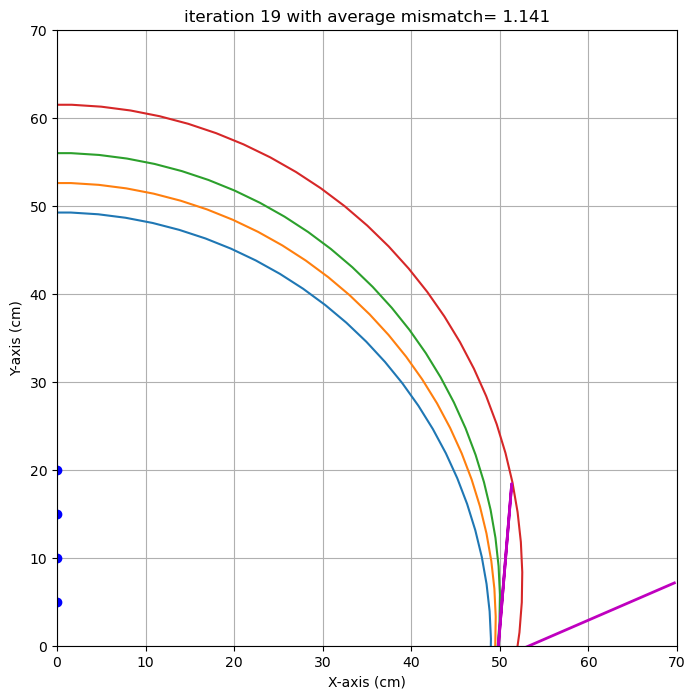

end iteration 19 with average mismatch= 1.141


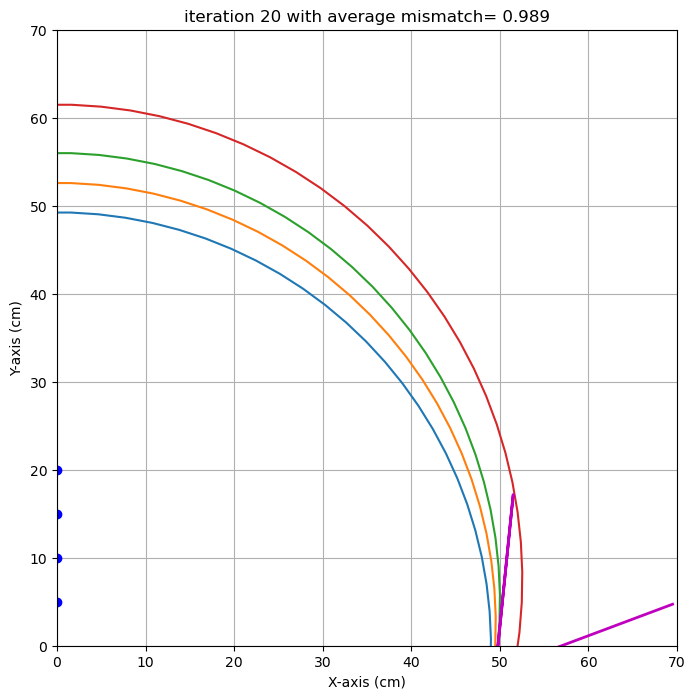

end iteration 20 with average mismatch= 0.989
end iteration 21 with average mismatch= 0.939


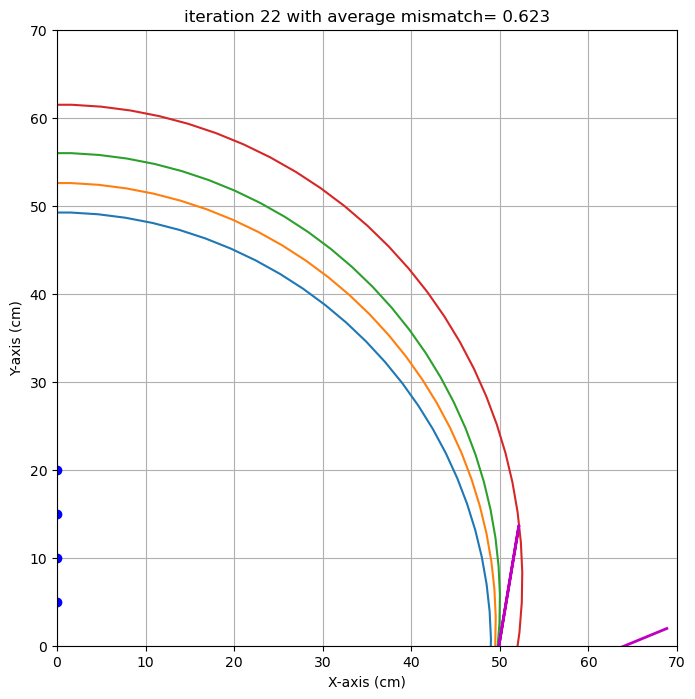

end iteration 22 with average mismatch= 0.623


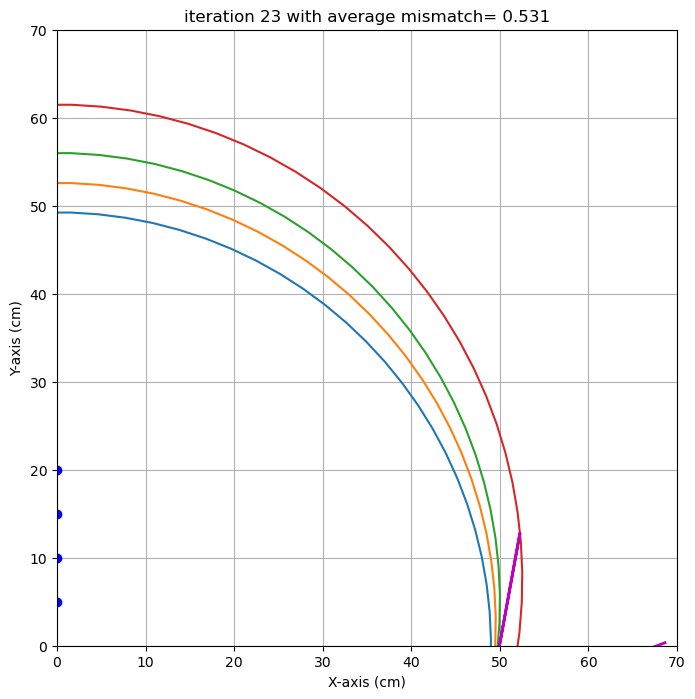

end iteration 23 with average mismatch= 0.531
end iteration 24 with average mismatch= 0.531
end iteration 25 with average mismatch= 0.531
end iteration 26 with average mismatch= 0.531
end iteration 27 with average mismatch= 0.531
end iteration 28 with average mismatch= 0.531
end iteration 29 with average mismatch= 0.531
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


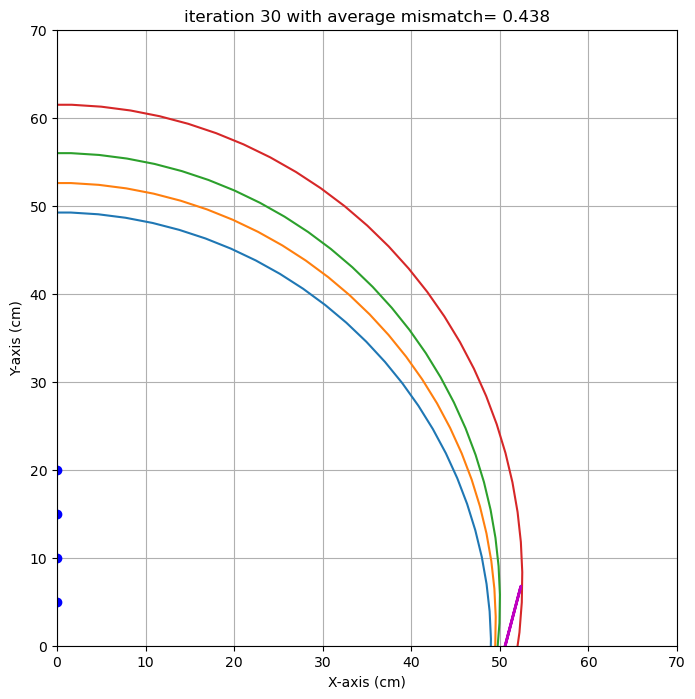

end iteration 30 with average mismatch= 0.438
###############################################################################
end of iteration  30
Best alpha=  29.80 with uncertainty=   8.85
Best beta =  14.67 with uncertainty=   3.05
Best x0   =  47.14 with uncertainty=   1.29
Best y0   = -13.23 with uncertainty=   3.79
###############################################################################


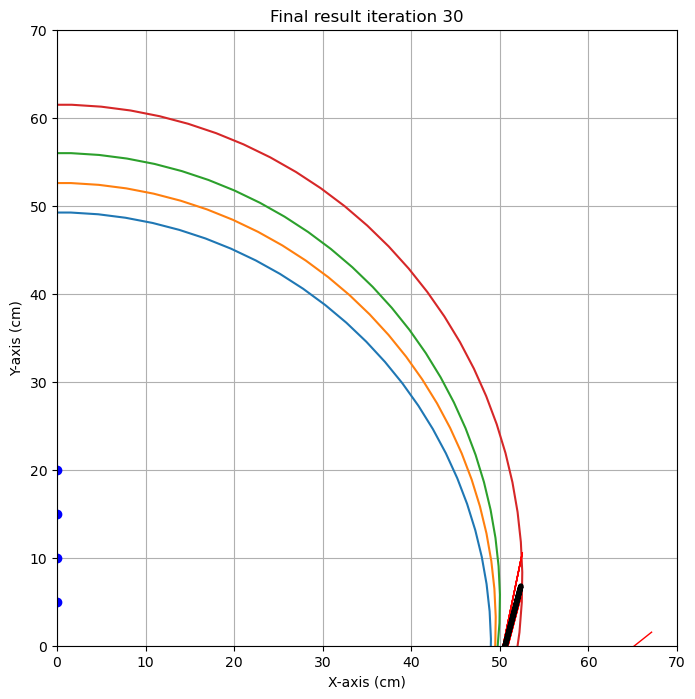

In [ ]:
# test meeeting 2

import pandas as pd
import numpy as np
import imagingDEF2024 as imagingDEF # Zorg dat dit bestand in dezelfde map staat


dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0, -5, 0,  5, 98.5],
    [0, -5, 0, 10, 100.2],  
    [0, -5, 0, 15, 102], 
    [0, -5, 0, 20, 108],  
])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  -5   0   5  100.54
1   0  -5   0  10  101.45
2   0  -5   0  15  103.20
3   0  -5   0  20  108.09


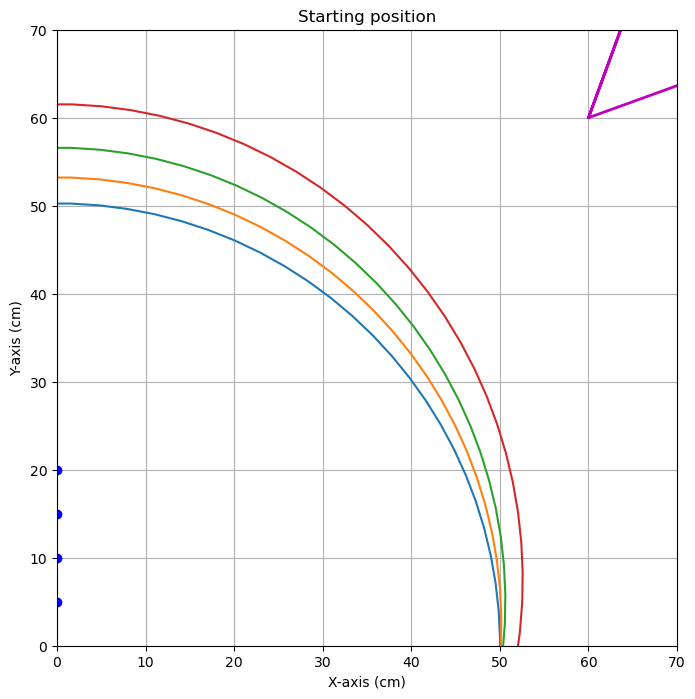


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=69.188


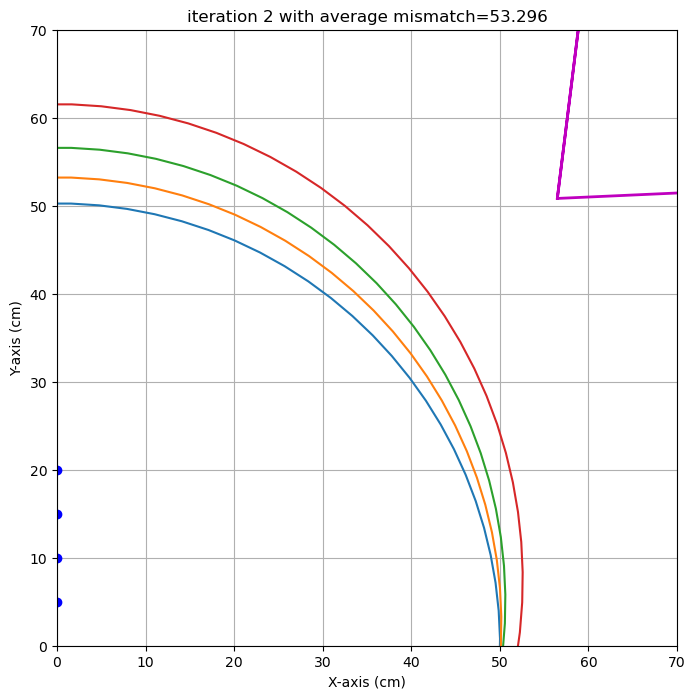

end iteration 2 with average mismatch=53.296


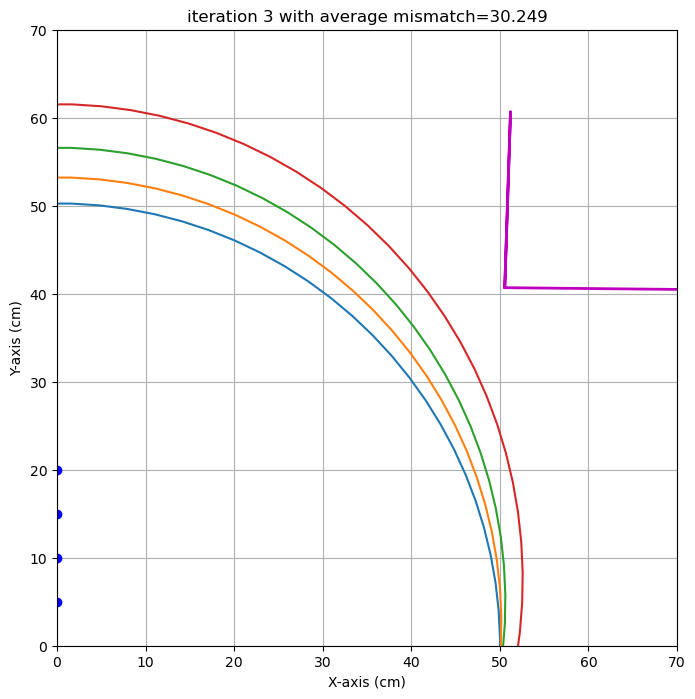

end iteration 3 with average mismatch=30.249


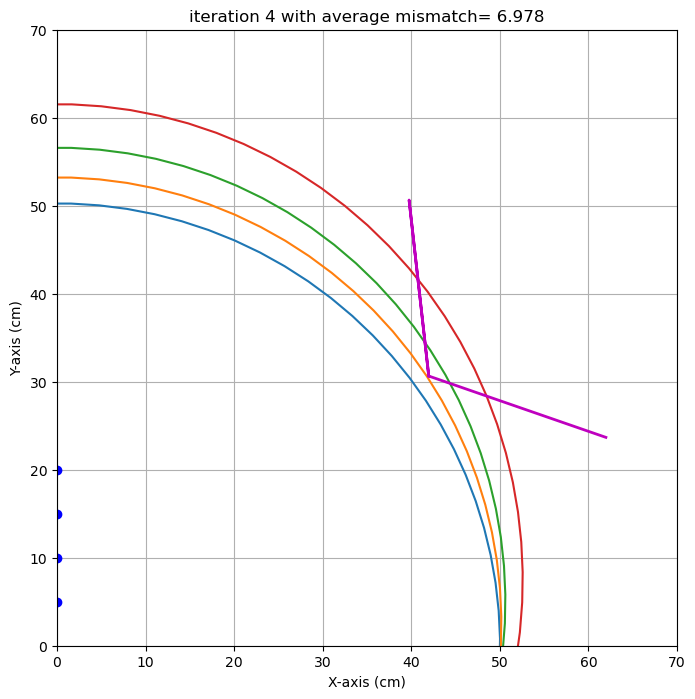

end iteration 4 with average mismatch= 6.978


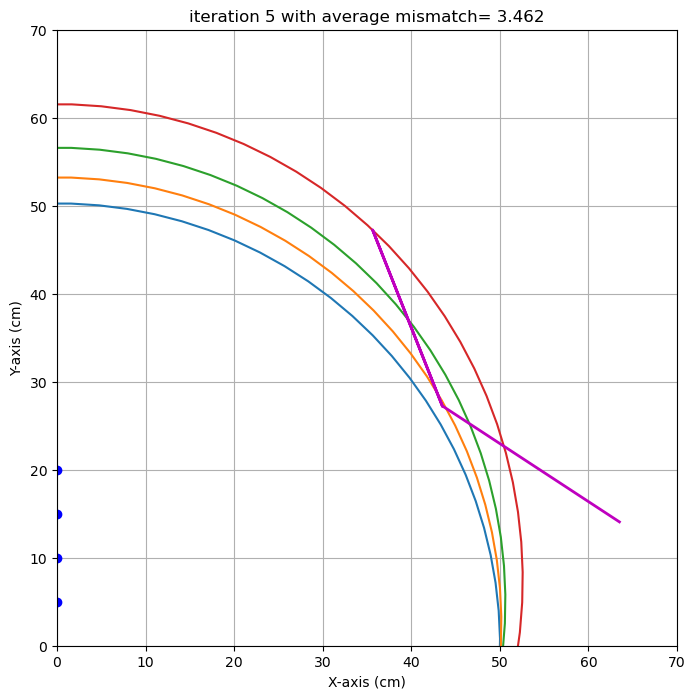

end iteration 5 with average mismatch= 3.462


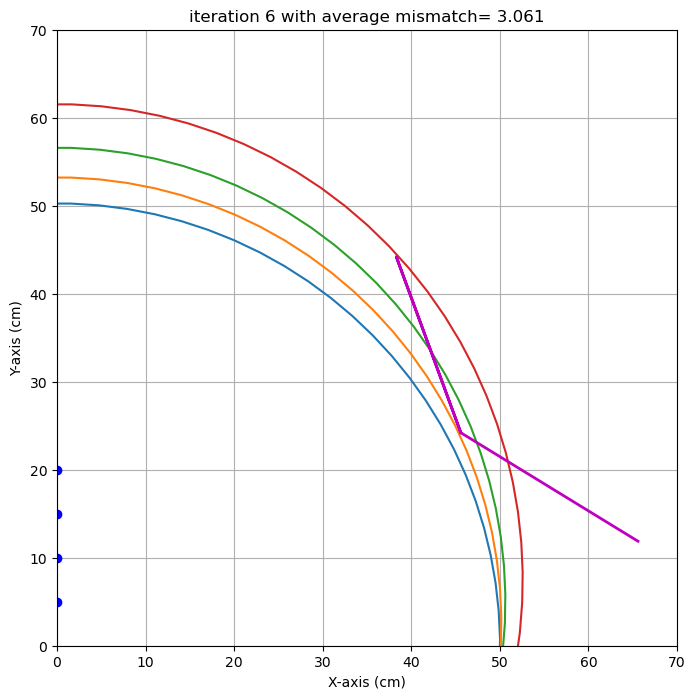

end iteration 6 with average mismatch= 3.061


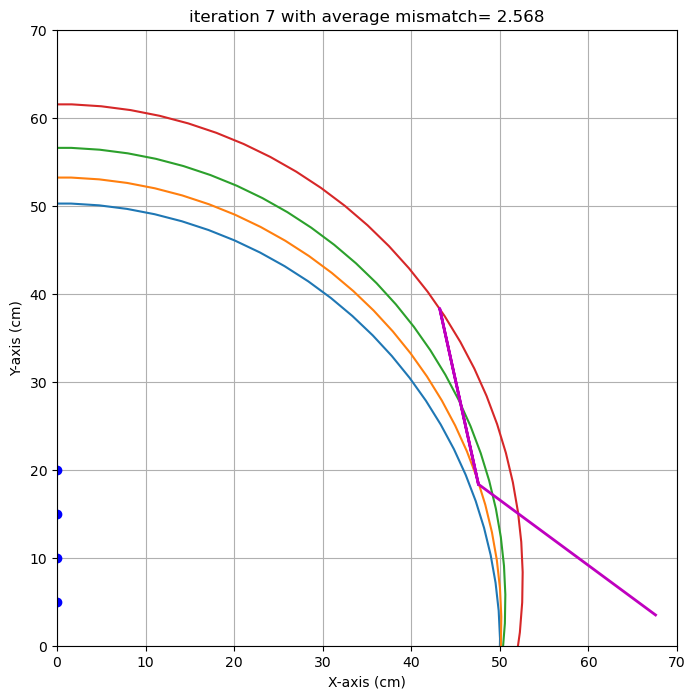

end iteration 7 with average mismatch= 2.568


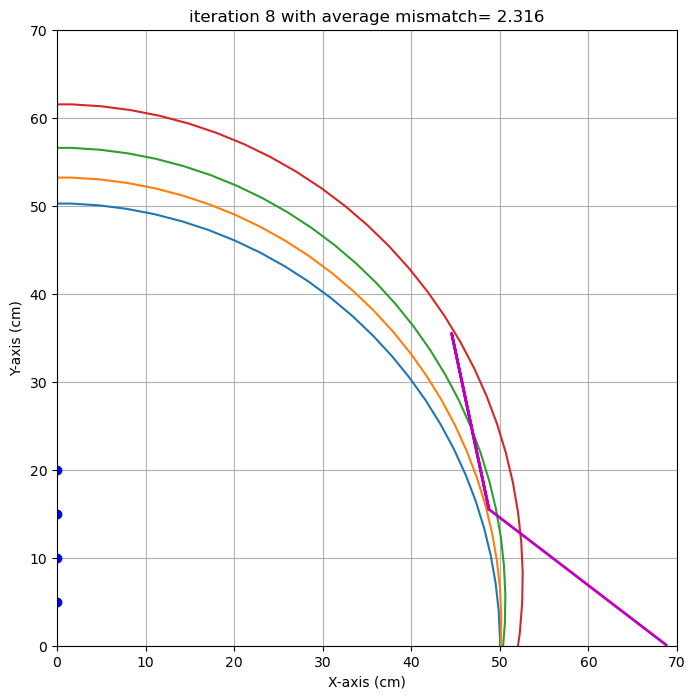

end iteration 8 with average mismatch= 2.316
end iteration 9 with average mismatch= 2.138


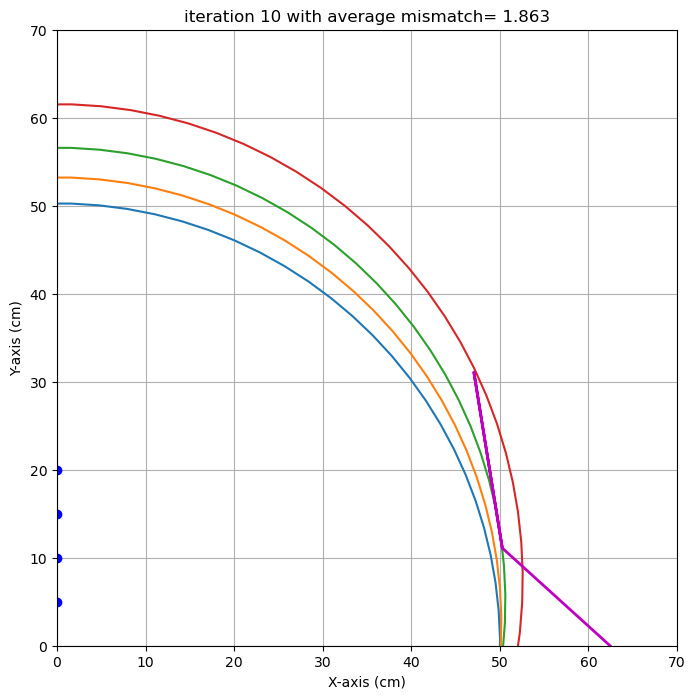

end iteration 10 with average mismatch= 1.863


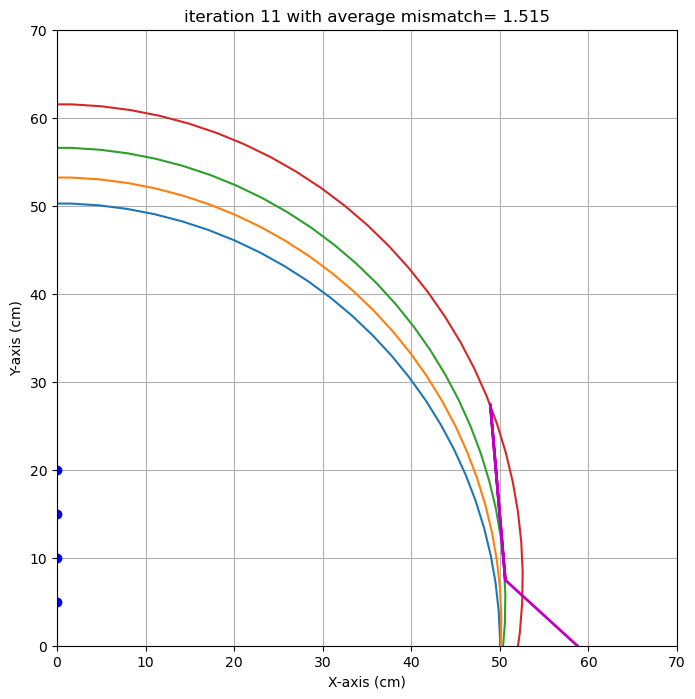

end iteration 11 with average mismatch= 1.515


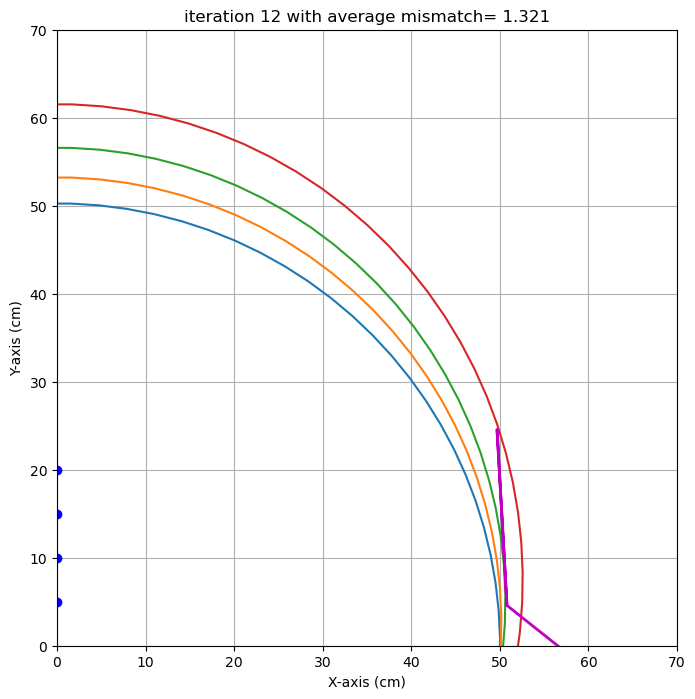

end iteration 12 with average mismatch= 1.321


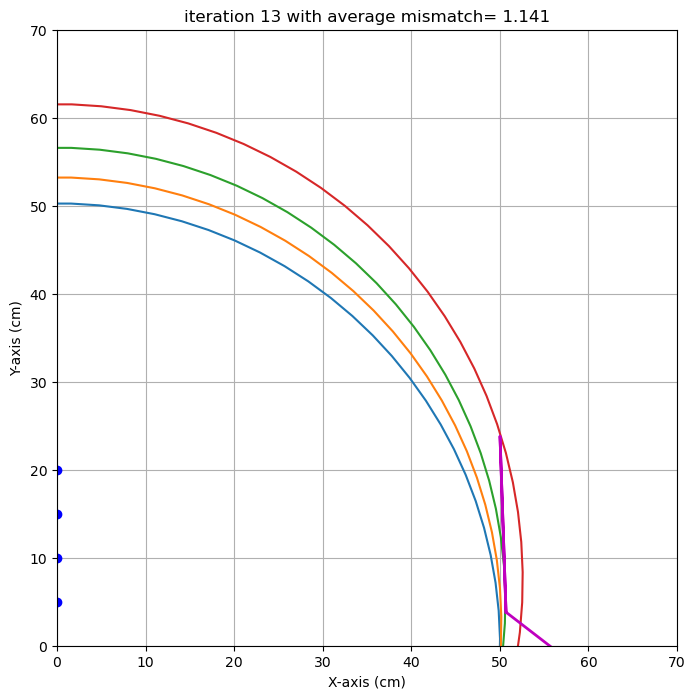

end iteration 13 with average mismatch= 1.141
end iteration 14 with average mismatch= 1.066
end iteration 15 with average mismatch= 0.975


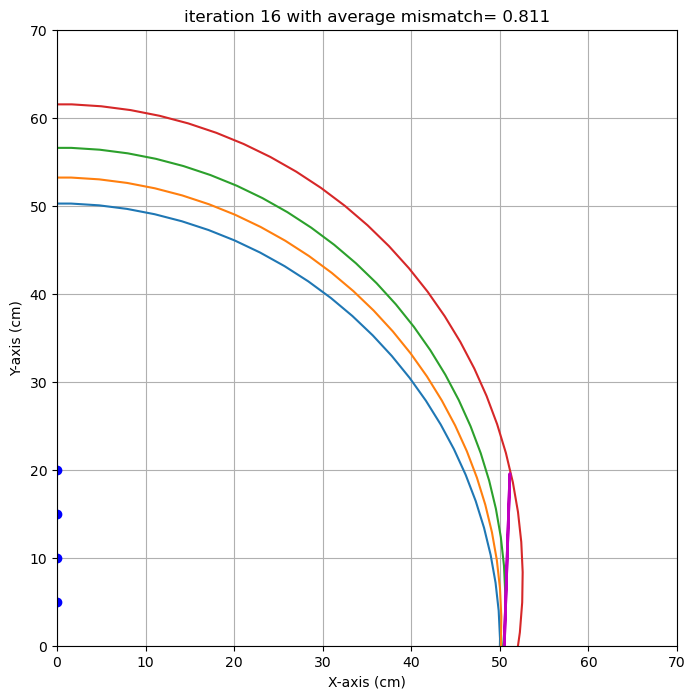

end iteration 16 with average mismatch= 0.811


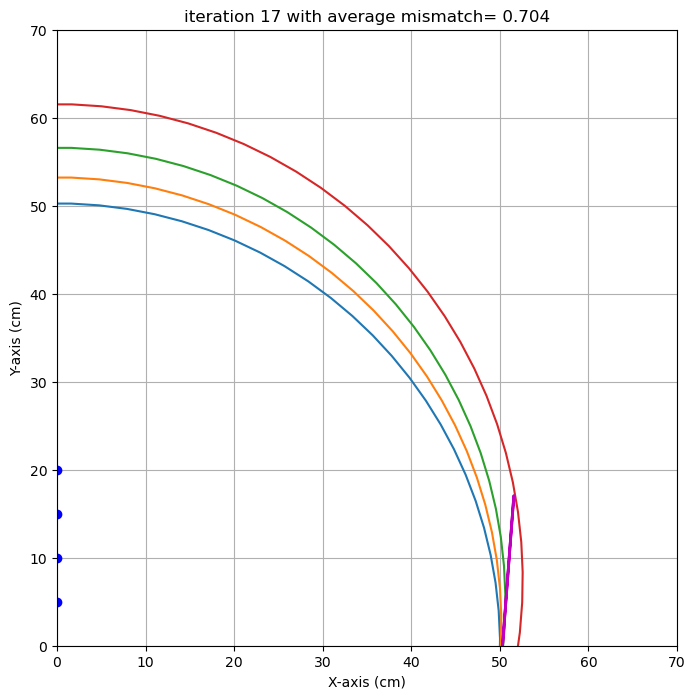

end iteration 17 with average mismatch= 0.704


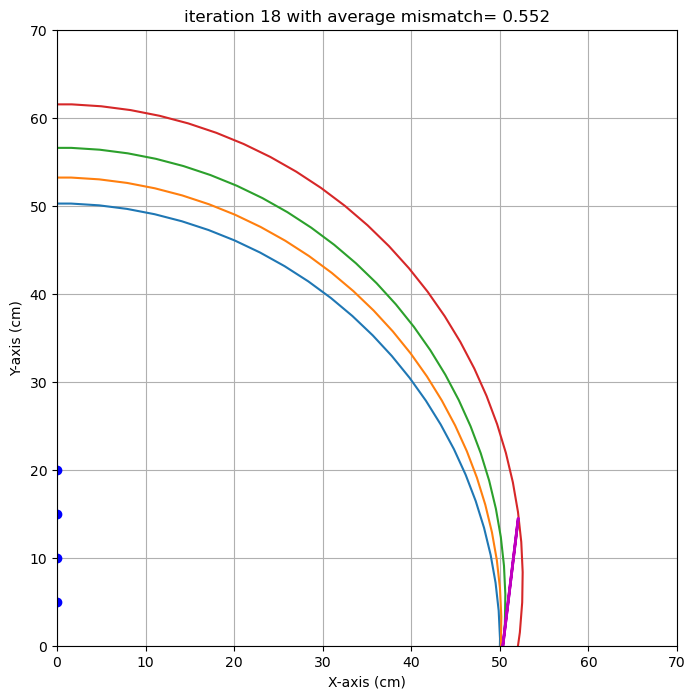

end iteration 18 with average mismatch= 0.552


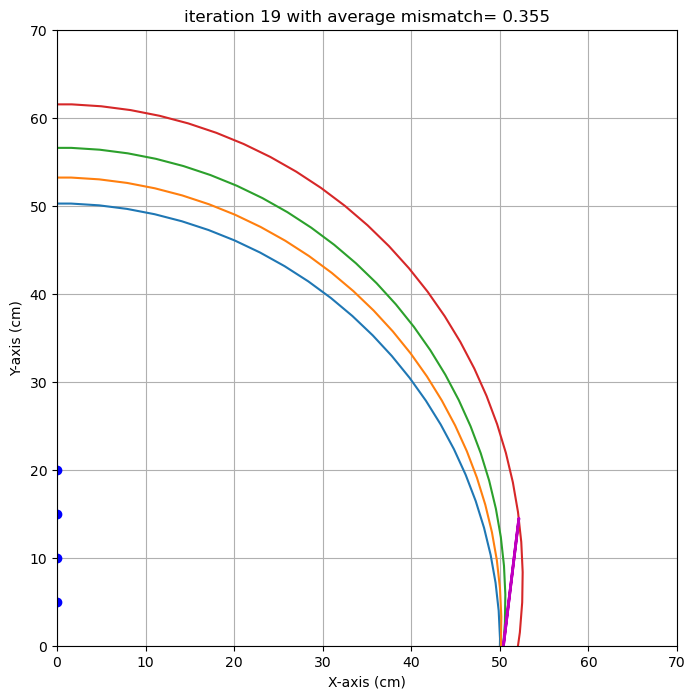

end iteration 19 with average mismatch= 0.355
end iteration 20 with average mismatch= 0.352
end iteration 21 with average mismatch= 0.350
end iteration 22 with average mismatch= 0.350
end iteration 23 with average mismatch= 0.350
end iteration 24 with average mismatch= 0.350
end iteration 25 with average mismatch= 0.350
end iteration 26 with average mismatch= 0.350
end iteration 27 with average mismatch= 0.350
end iteration 28 with average mismatch= 0.350
end iteration 29 with average mismatch= 0.350
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.350
###############################################################################
end of iteration  30
Best alpha= -31.65 with uncertainty=  13.48
Best beta =   6.87 with uncertainty=   3.36
Best x0   =  49.73 with uncertainty=   0.86
Best y0   =  -5.52 with uncertainty=   4.45
##############################################################

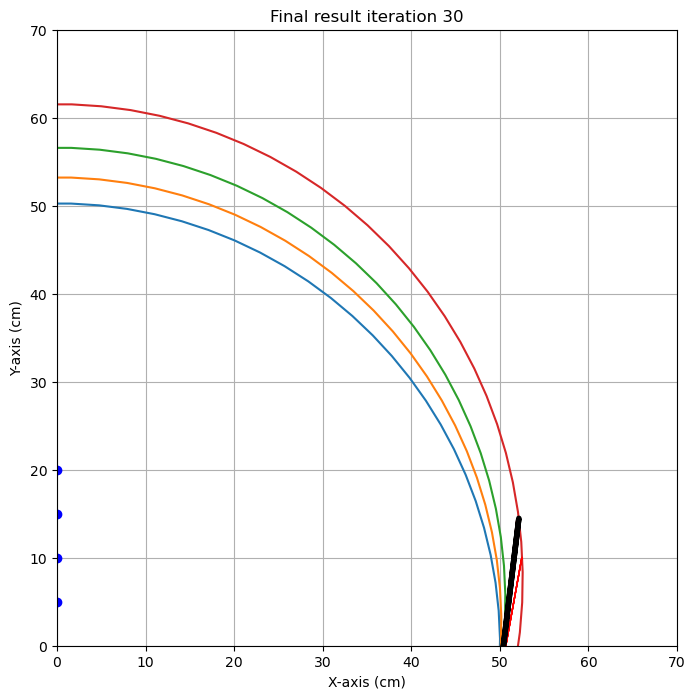

In [ ]:
# test meeting 3
import pandas as pd
import numpy as np
import imagingDEF2024 as imagingDEF 


dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0, -5, 0,  5, 100.54], 
    [0, -5, 0, 10, 101.45],  
    [0, -5, 0, 15, 103.2],  
    [0, -5, 0, 20, 108.09],  
])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  -5   0   5  100.54
1   0 -10   0  10  102.80
2   0 -15   0  15  105.80


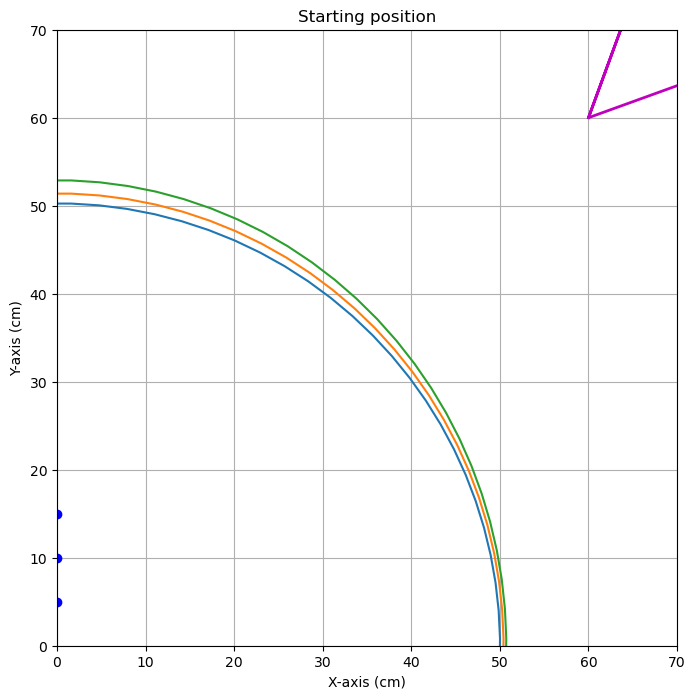


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=74.917


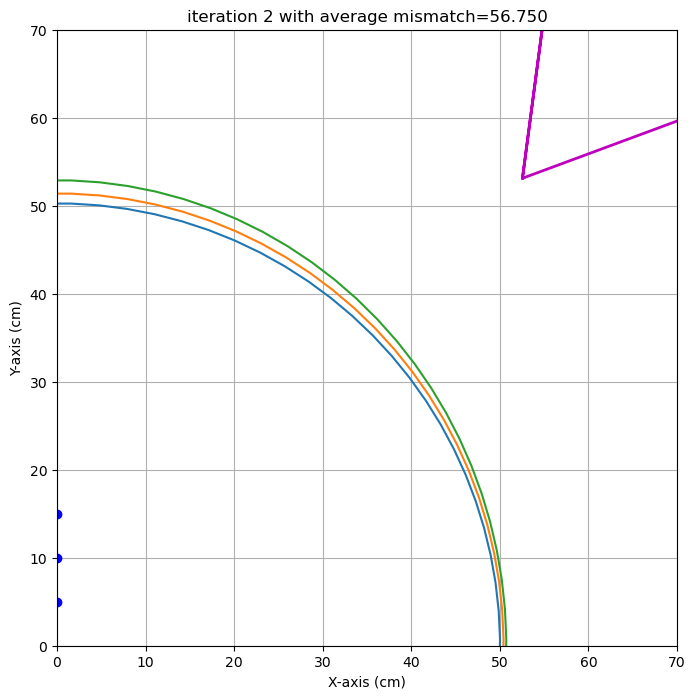

end iteration 2 with average mismatch=56.750


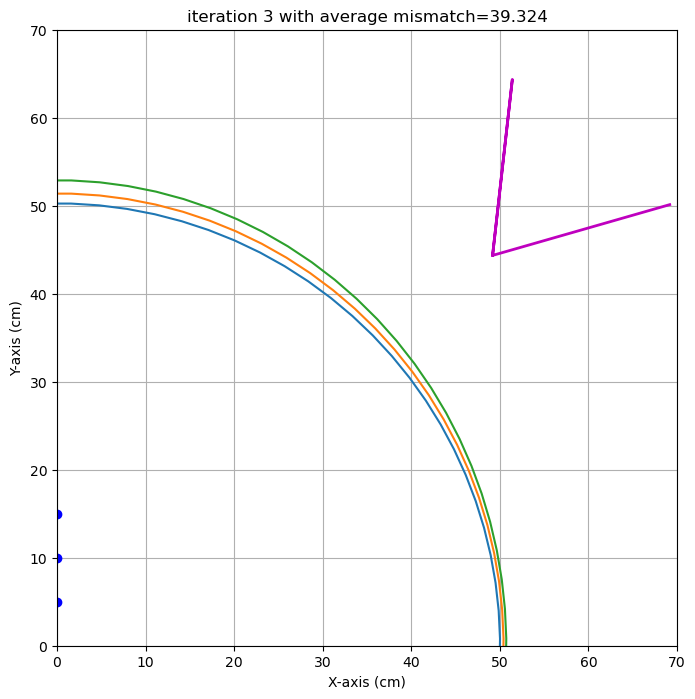

end iteration 3 with average mismatch=39.324


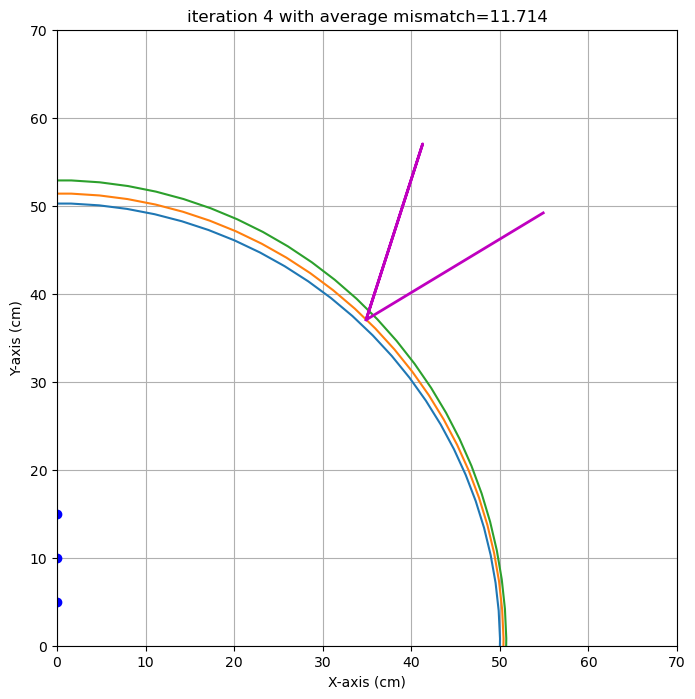

end iteration 4 with average mismatch=11.714


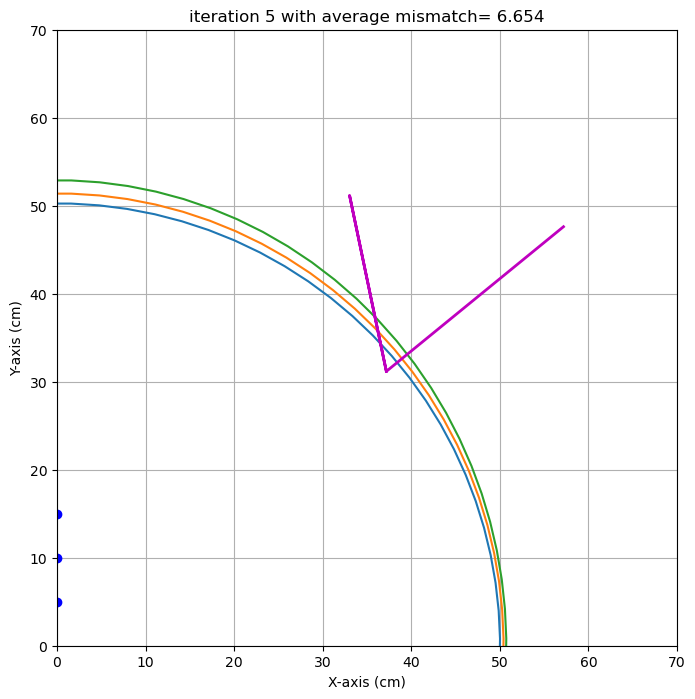

end iteration 5 with average mismatch= 6.654


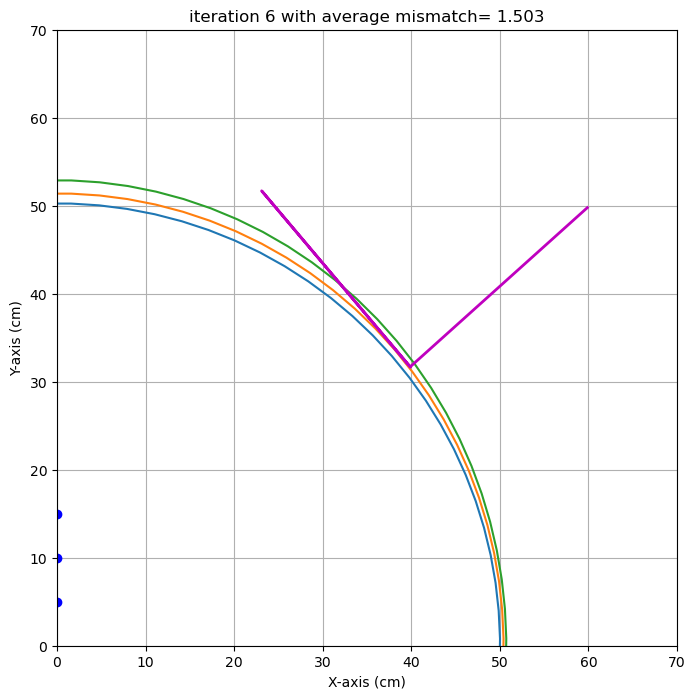

end iteration 6 with average mismatch= 1.503
end iteration 7 with average mismatch= 1.472
end iteration 8 with average mismatch= 1.439
end iteration 9 with average mismatch= 1.417
end iteration 10 with average mismatch= 1.416
end iteration 11 with average mismatch= 1.415
end iteration 12 with average mismatch= 1.415
end iteration 13 with average mismatch= 1.413
end iteration 14 with average mismatch= 1.338
end iteration 15 with average mismatch= 1.289
end iteration 16 with average mismatch= 1.286
end iteration 17 with average mismatch= 1.286
end iteration 18 with average mismatch= 1.286
end iteration 19 with average mismatch= 1.286
end iteration 20 with average mismatch= 1.286
end iteration 21 with average mismatch= 1.286
end iteration 22 with average mismatch= 1.232
end iteration 23 with average mismatch= 1.221
end iteration 24 with average mismatch= 1.216
end iteration 25 with average mismatch= 1.196
end iteration 26 with average mismatch= 1.164
end iteration 27 with average mismatch

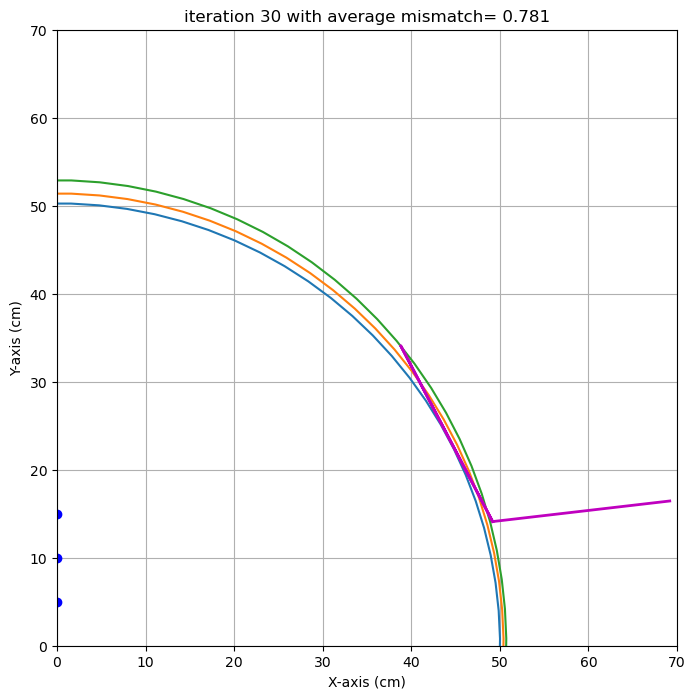

end iteration 30 with average mismatch= 0.781
###############################################################################
end of iteration  30
Best alpha=   6.67 with uncertainty=  14.95
Best beta = -27.44 with uncertainty=  14.77
Best x0   =  49.18 with uncertainty=   3.97
Best y0   =  14.11 with uncertainty=   4.97
###############################################################################


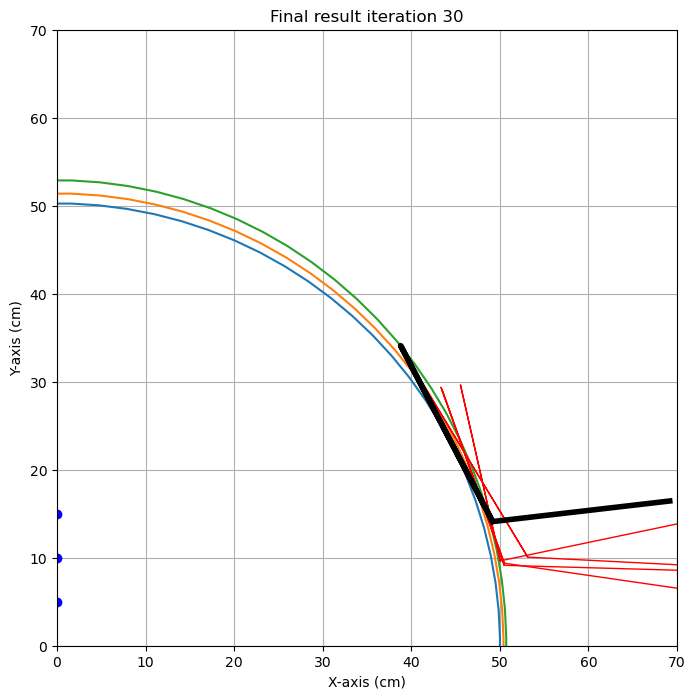

In [32]:
# test meeeting 4

import pandas as pd
import numpy as np
import imagingDEF2024 as imagingDEF 


dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0, -5, 0,  5, 100.54],  
    [0, -10, 0, 10, 102.8],  
    [0, -15, 0, 15, 105.8],  
])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [24]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 51.0 cm met een standaardafwijking van 3.6 cm 
y0: 4.8 cm met een standaardafwijking van 5.0 cm 
alpha: 42.3 graden met een standaardafwijking van 14.6 graad 
beta: -17.1 graden met een standaardafwijking van 14.6 graad 



**reflectie opdracht 4**

Hoewel de berekende afstand ($x_0 = 51.0$ cm) zeer dicht bij de werkelijke waarde van 50 cm ligt, zien we een grotere onzekerheid en afwijking bij de zijwaartse positie ($y_0$) en de hoek ($\alpha$). Dit heeft waarschijnlijk drie hoofdoorzaken:

- Beperkt aantal meetpunten: Voor deze check zijn slechts drie metingen gebruikt ($d=5, 10, 15$). Hierdoor heeft het algoritme weinig data om meetruis "weg te middelen". Een kleine afwijking in één van de $R$-waarden heeft direct een grote impact op de berekende hoek.
- Toenemende afwijking bij grotere hoeken: Bij de meting op $d=15$ cm zagen we een groter verschil tussen de theorie en de praktijk (ca. 1.4 cm). Omdat de sensoren hier verder uit elkaar staan, raakt de ultrasone bundel het object onder een grotere hoek. Dit kan leiden tot indirecte reflecties of een verschuiving van het reflectiepunt op het 10 cm brede karton.
- Geometrische gevoeligheid: Het algoritme zoekt naar het snijpunt van ellipsen. Wanneer ellipsen elkaar onder een flauwe hoek snijden, zorgt een kleine variatie in de gemeten afstand $R$ voor een relatief grote verschuiving van het berekende snijpunt op de y-as.

## Opdracht 5: Iteratie 0

#### algoritme [Thijmen]
FSchematische weergave van het imaging-algoritme. Door de totale afstand $R$ te meten voor verschillende ontvangerposities ($R_1, R_2$), worden ellipsen geconstrueerd. Het snijpunt van deze ellipsen bepaalt de coördinaten $(x_0, y_0)$ van het object.

"<img src="algoritme.png" width="400">


## Opdracht 6: Test iteratie 0.

Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0   5   0 -20  107.20
1   0   5   0 -15  104.50
2   0   5   0 -10  101.20
3   0   5   0  -5   99.90
4   0  -5   0   5  100.52
5   0  -5   0  10  101.20
6   0  -5   0  15  104.80


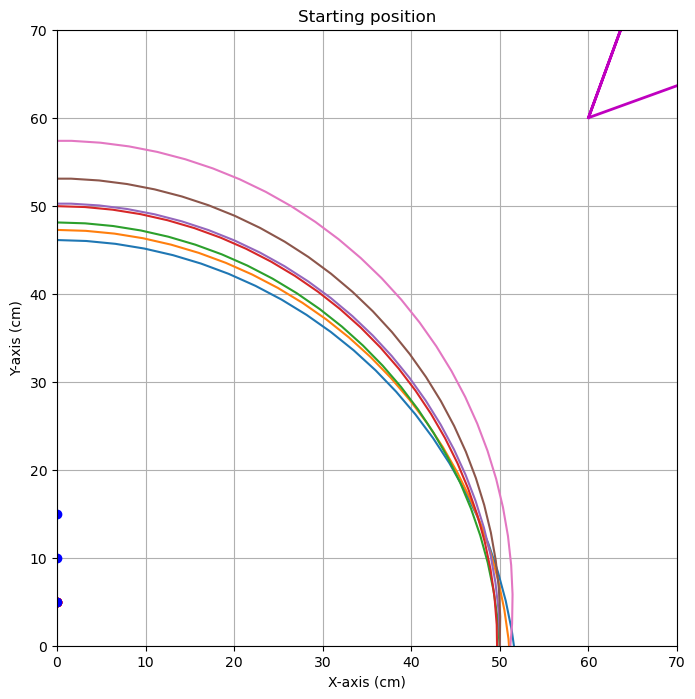


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=76.606


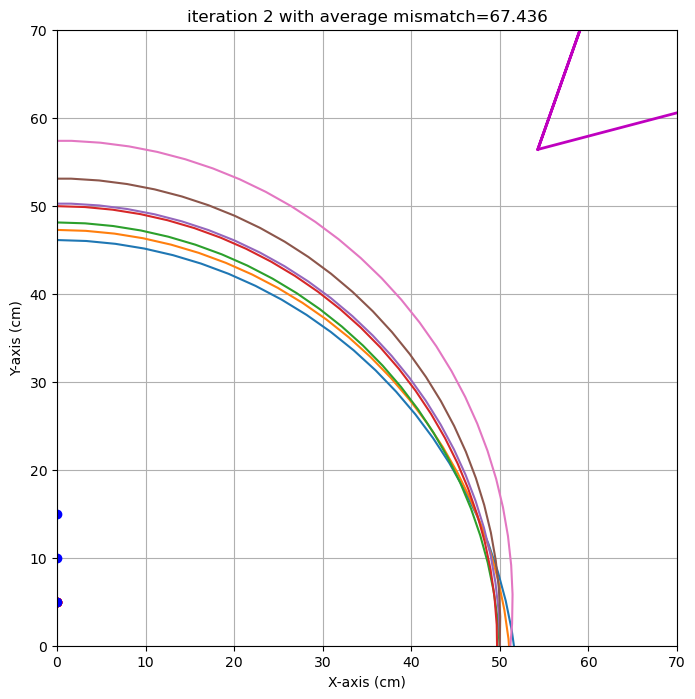

end iteration 2 with average mismatch=67.436


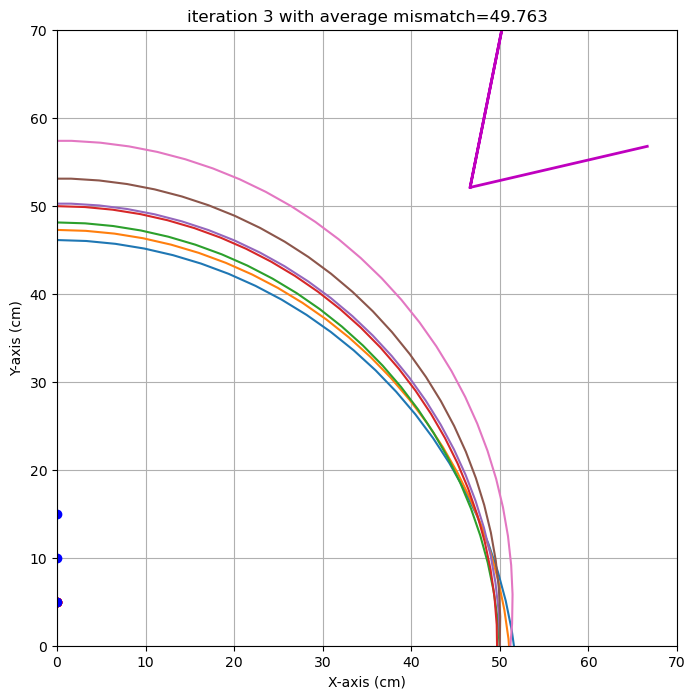

end iteration 3 with average mismatch=49.763


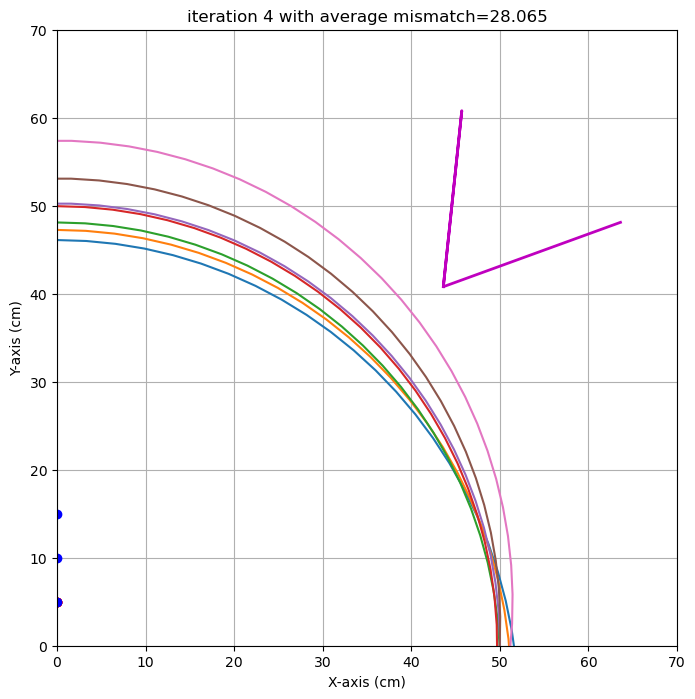

end iteration 4 with average mismatch=28.065


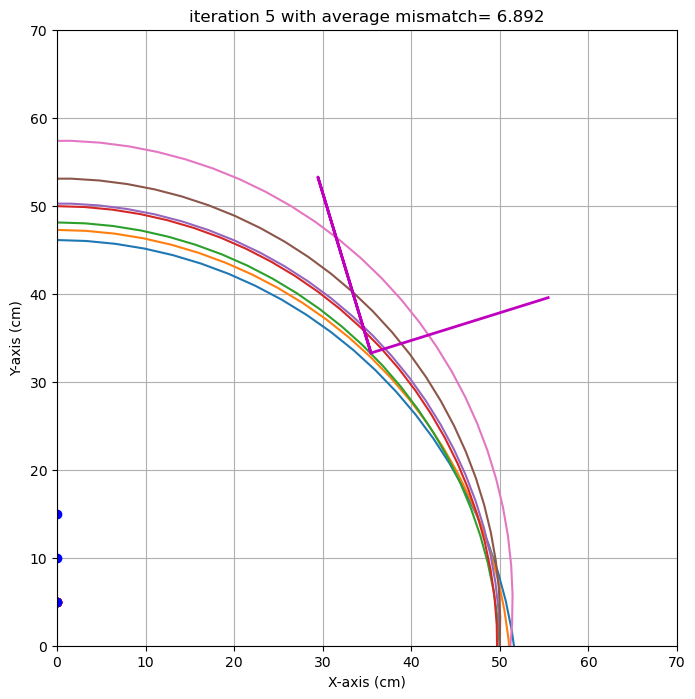

end iteration 5 with average mismatch= 6.892


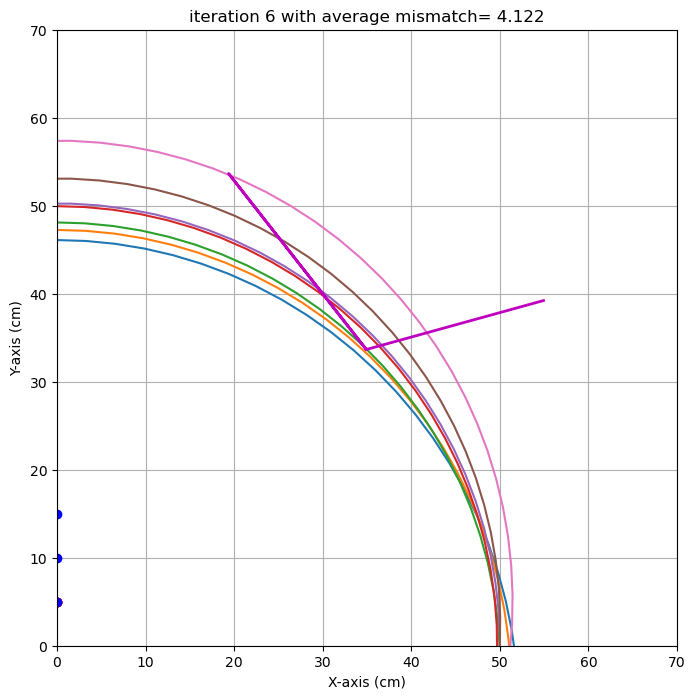

end iteration 6 with average mismatch= 4.122


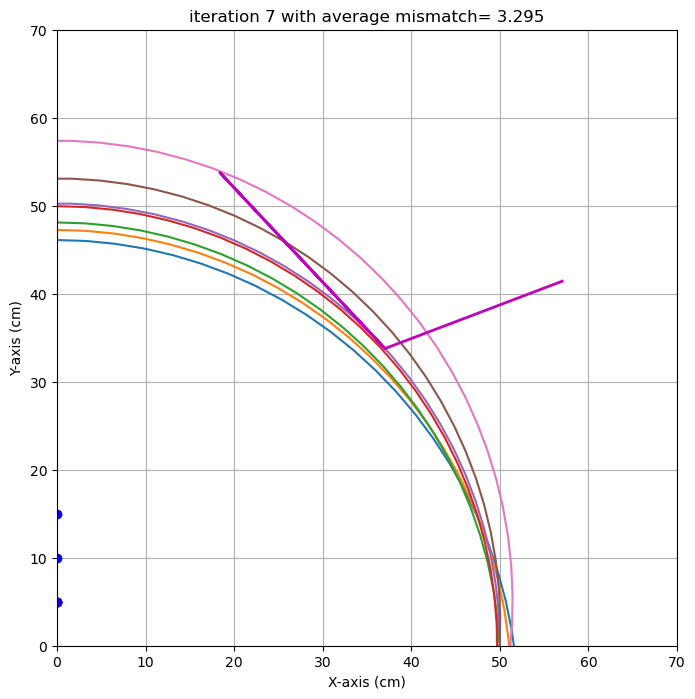

end iteration 7 with average mismatch= 3.295
end iteration 8 with average mismatch= 3.292
end iteration 9 with average mismatch= 3.291
end iteration 10 with average mismatch= 3.291
end iteration 11 with average mismatch= 3.239
end iteration 12 with average mismatch= 3.239
end iteration 13 with average mismatch= 3.239
end iteration 14 with average mismatch= 3.238
end iteration 15 with average mismatch= 3.238
end iteration 16 with average mismatch= 3.230
end iteration 17 with average mismatch= 3.228
end iteration 18 with average mismatch= 3.225
end iteration 19 with average mismatch= 3.218
end iteration 20 with average mismatch= 3.215
end iteration 21 with average mismatch= 3.212
end iteration 22 with average mismatch= 3.211
end iteration 23 with average mismatch= 3.211
end iteration 24 with average mismatch= 3.211
end iteration 25 with average mismatch= 3.211
end iteration 26 with average mismatch= 3.211
end iteration 27 with average mismatch= 3.210
end iteration 28 with average mismatc

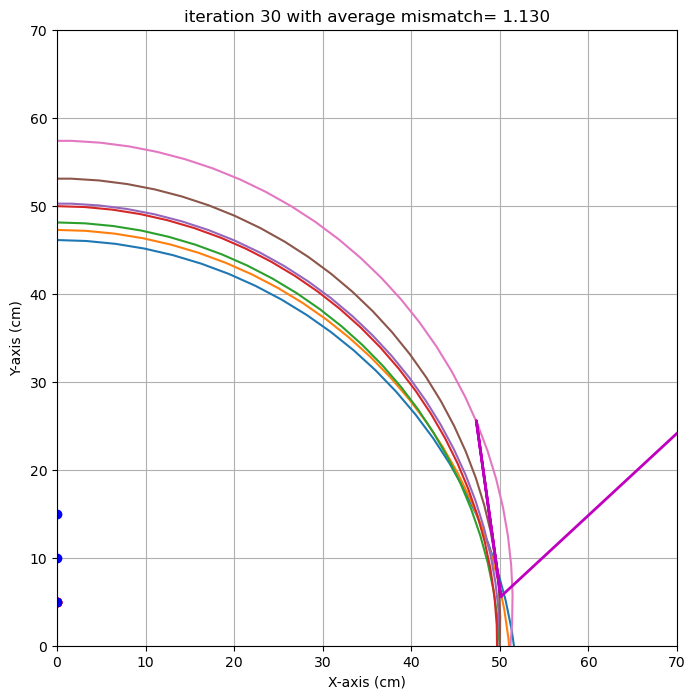

end iteration 30 with average mismatch= 1.130
###############################################################################
end of iteration  30
Best alpha=  43.00 with uncertainty=  14.55
Best beta =  -7.88 with uncertainty=  12.79
Best x0   =  50.10 with uncertainty=   2.81
Best y0   =   5.59 with uncertainty=   4.99
###############################################################################


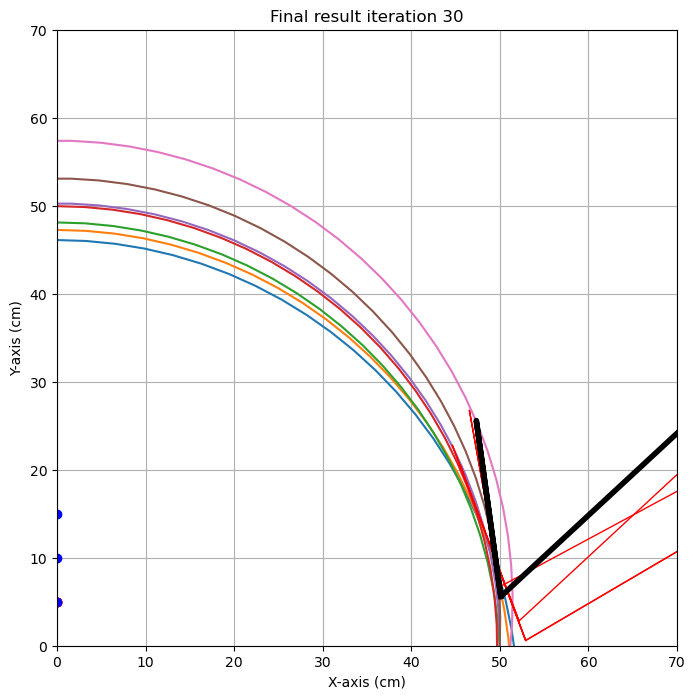

In [ ]:
targets = {
    'x0': 50.0,    # Je hebt het object op 50 cm gezet
    'y0': 0.0,     # Het staat precies in het midden
    'alpha': 90.0, # Het staat kaarsrecht
    'beta': 10.0   # Het karton is 10 cm breed
}

data = {
    'Meting_1': pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        [0, 5, 0, -20, 107.2], # [xs, ys, xr, yr, BEREKENDE R IN CM]
        [0, 5, 0, -15, 104.5],
        [0, 5, 0, -10, 101.2],
        [0, 5, 0,  -5, 99.9],
        [0, -5, 0,  5, 100.52],
        [0, -5, 0,  10, 101.2],
        [0, -5, 0,  15, 104.8]
    ])
}

## Opdracht 7: Evaluatie.

In [28]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 51.0 cm met een standaardafwijking van 3.6 cm 
y0: 4.8 cm met een standaardafwijking van 5.0 cm 
alpha: 42.3 graden met een standaardafwijking van 14.6 graad 
beta: -17.1 graden met een standaardafwijking van 14.6 graad 



## Opdracht 8: Iteratie1+.
### Synthese
In Iteratie 1 passen we het algoritme aan door gebruik te maken van een grotere dataset (7 meetpunten in plaats van 3) en een symmetrische sensor-opstelling. Hierdoor verlagen we de standaardafwijking ($\epsilon$) en kan het algoritme de hoek $\alpha$ nauwkeuriger bepalen via de 'Least Squares' methode

Figuur: ![Alt](twee.jpg)


## Opdracht 9: Iteratie 1+ meeting en test

Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0   5   0 -20  101.37
1   0   5   0 -10  100.50
2   0   5   0   0  100.25
3   0   5   0  10  100.50
4   0  -5   0 -10  100.50
5   0  -5   0   0  100.25
6   0  -5   0  10  100.50
7   0  -5   0  20  101.37


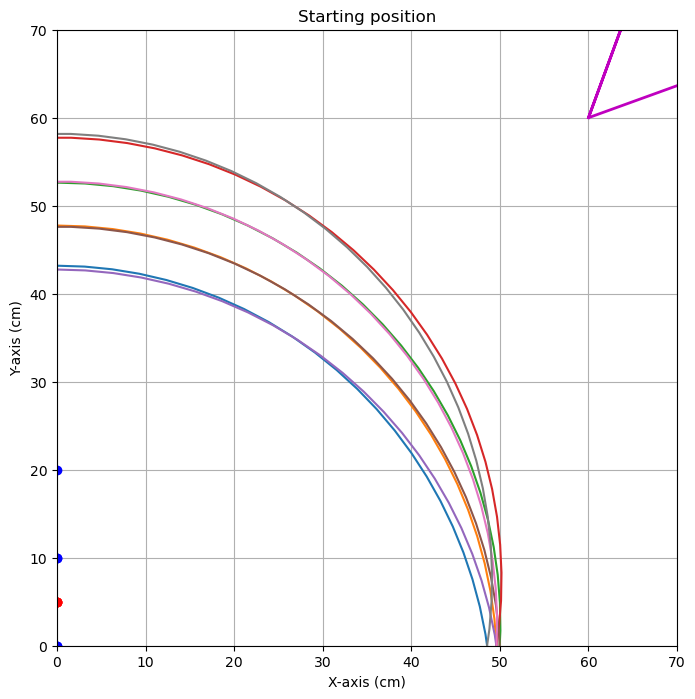


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=77.156


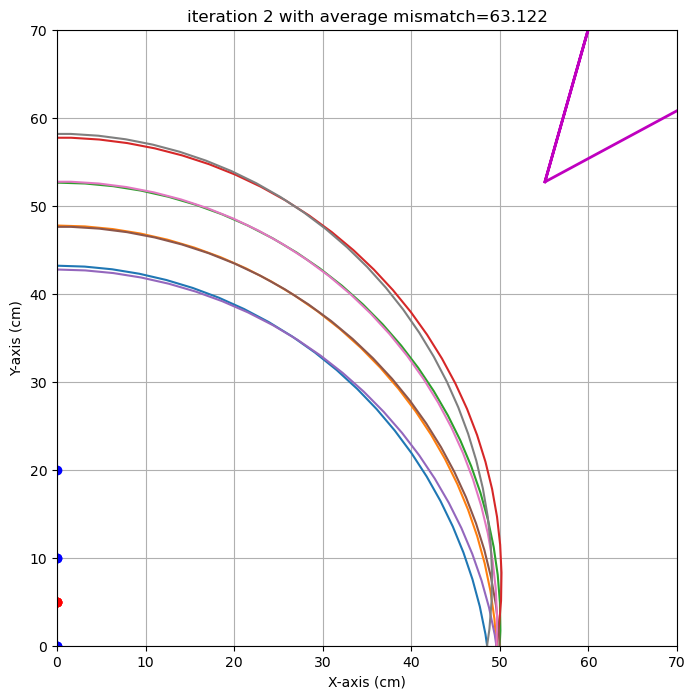

end iteration 2 with average mismatch=63.122


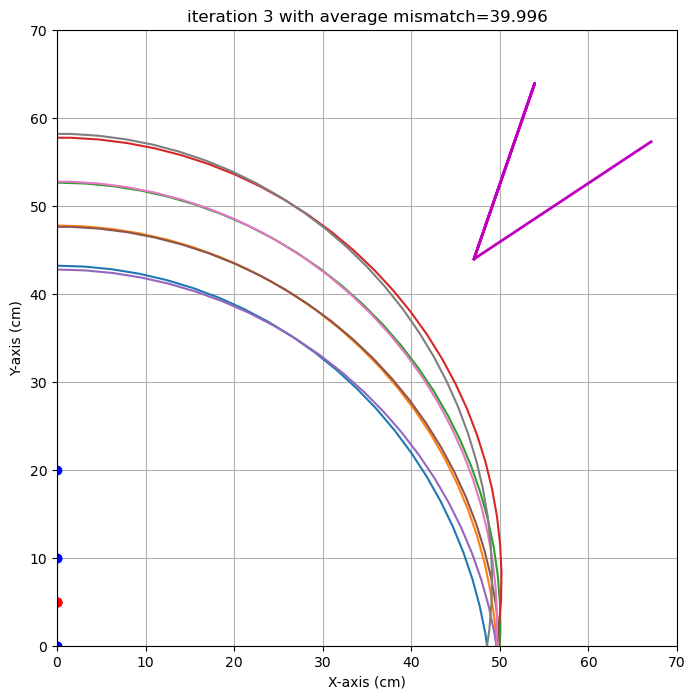

end iteration 3 with average mismatch=39.996


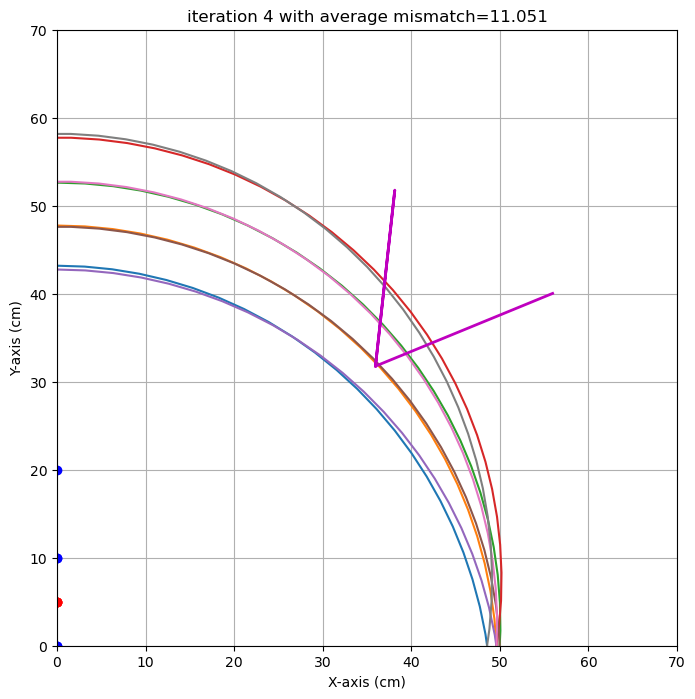

end iteration 4 with average mismatch=11.051


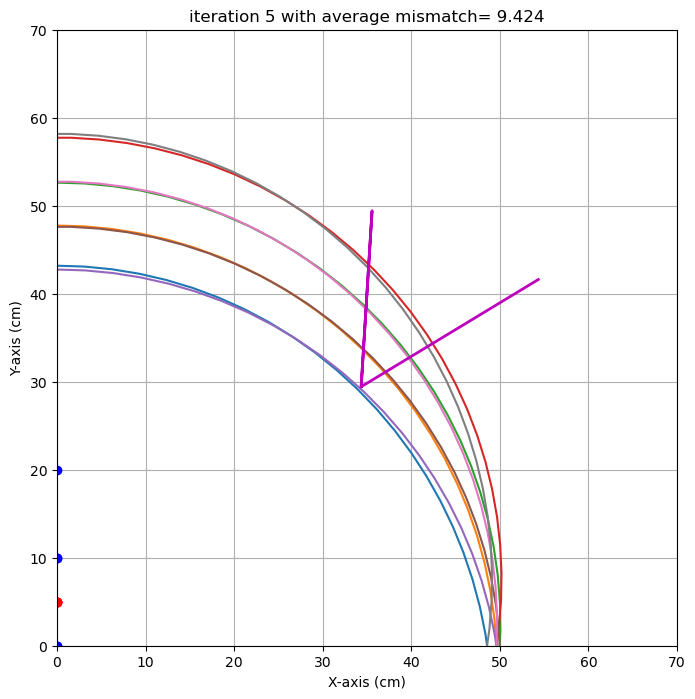

end iteration 5 with average mismatch= 9.424
end iteration 6 with average mismatch= 9.152


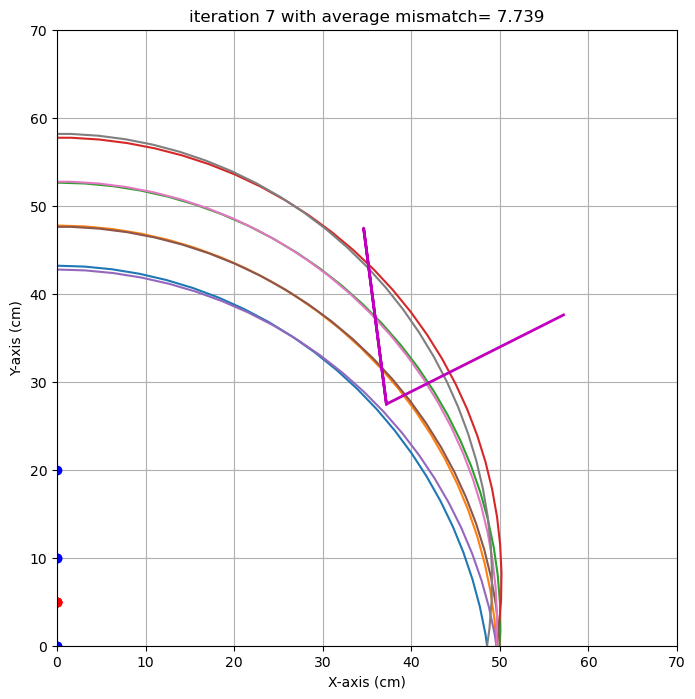

end iteration 7 with average mismatch= 7.739
end iteration 8 with average mismatch= 7.216


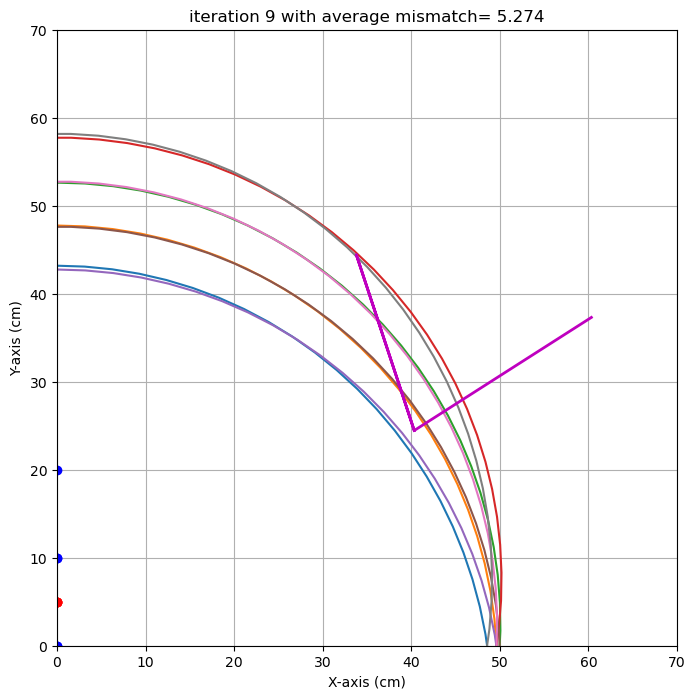

end iteration 9 with average mismatch= 5.274
end iteration 10 with average mismatch= 5.063


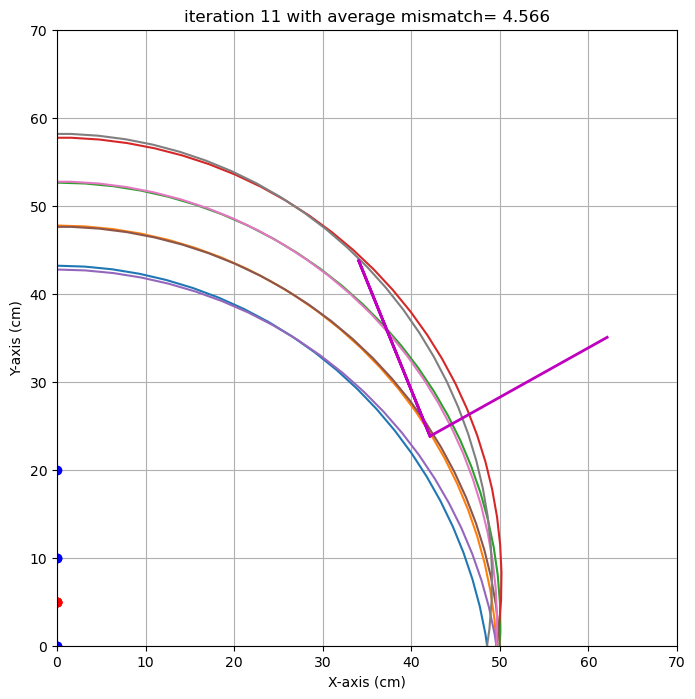

end iteration 11 with average mismatch= 4.566
end iteration 12 with average mismatch= 4.515
end iteration 13 with average mismatch= 4.162
end iteration 14 with average mismatch= 3.798
end iteration 15 with average mismatch= 3.798
end iteration 16 with average mismatch= 3.792
end iteration 17 with average mismatch= 3.792
end iteration 18 with average mismatch= 3.792
end iteration 19 with average mismatch= 3.682
end iteration 20 with average mismatch= 3.682
end iteration 21 with average mismatch= 3.682
end iteration 22 with average mismatch= 3.446
end iteration 23 with average mismatch= 3.316
end iteration 24 with average mismatch= 3.316
end iteration 25 with average mismatch= 3.258
end iteration 26 with average mismatch= 3.258
end iteration 27 with average mismatch= 3.258
end iteration 28 with average mismatch= 3.258
end iteration 29 with average mismatch= 3.257
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


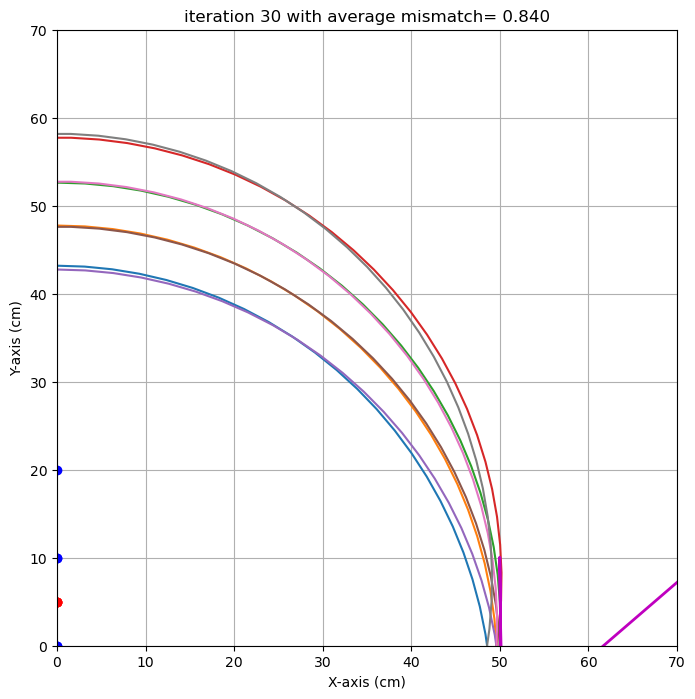

end iteration 30 with average mismatch= 0.840
###############################################################################
end of iteration  30
Best alpha=  40.92 with uncertainty=  14.93
Best beta =  -0.69 with uncertainty=   6.32
Best x0   =  50.23 with uncertainty=   1.59
Best y0   =  -9.94 with uncertainty=   5.00
###############################################################################


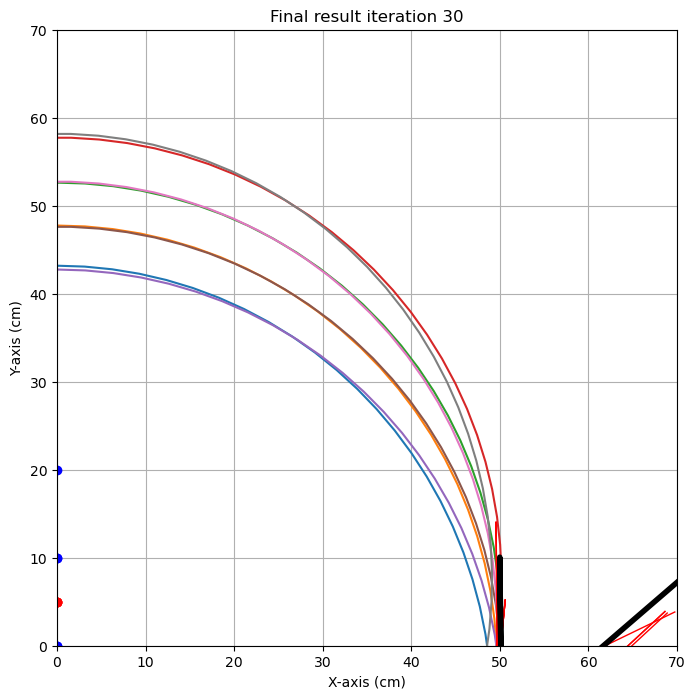

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0   5   0 -20  99.41
1   0   5   0 -10  93.72
2   0   5   0   0  90.31
3   0   5   0  10  89.24
4   0  -5   0 -10  96.58
5   0  -5   0   0  92.42
6   0  -5   0  10  90.31
7   0  -5   0  20  89.84


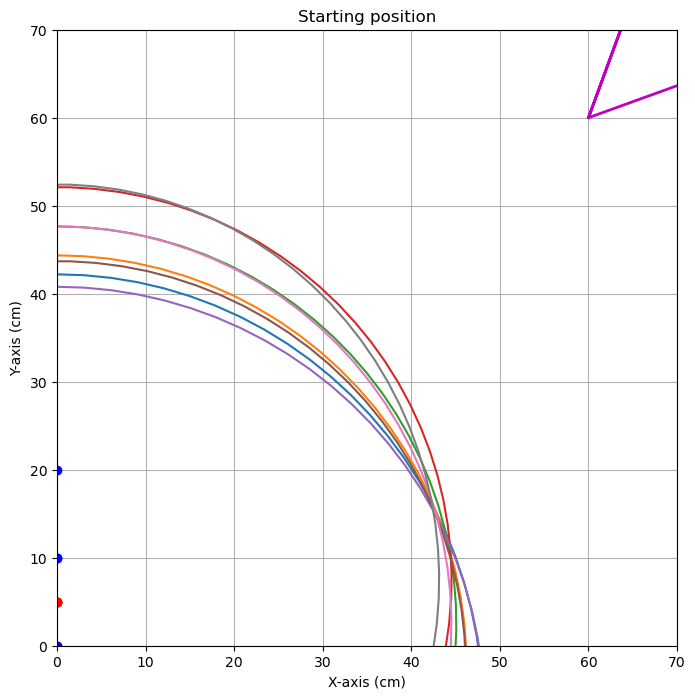


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.082


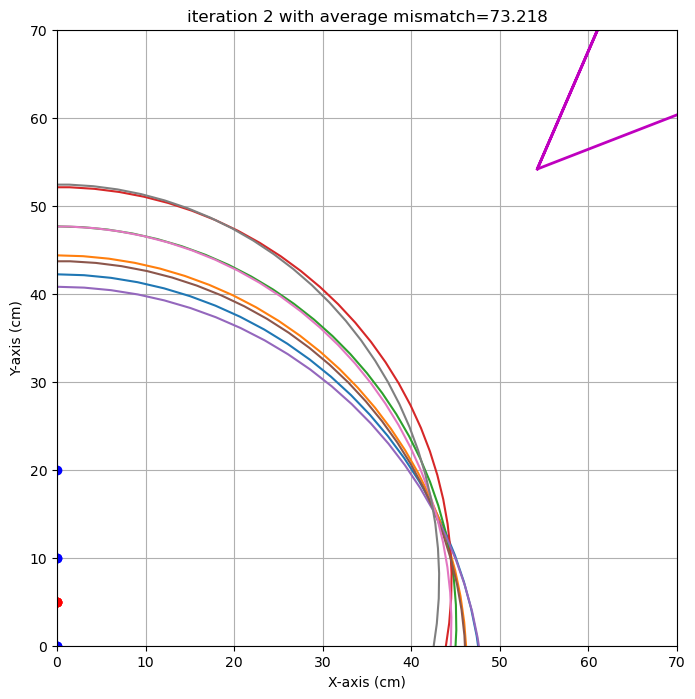

end iteration 2 with average mismatch=73.218


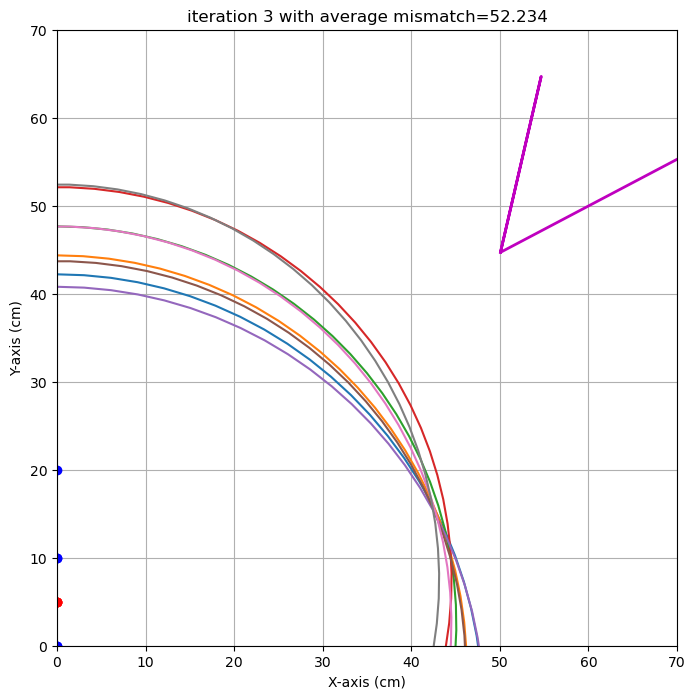

end iteration 3 with average mismatch=52.234


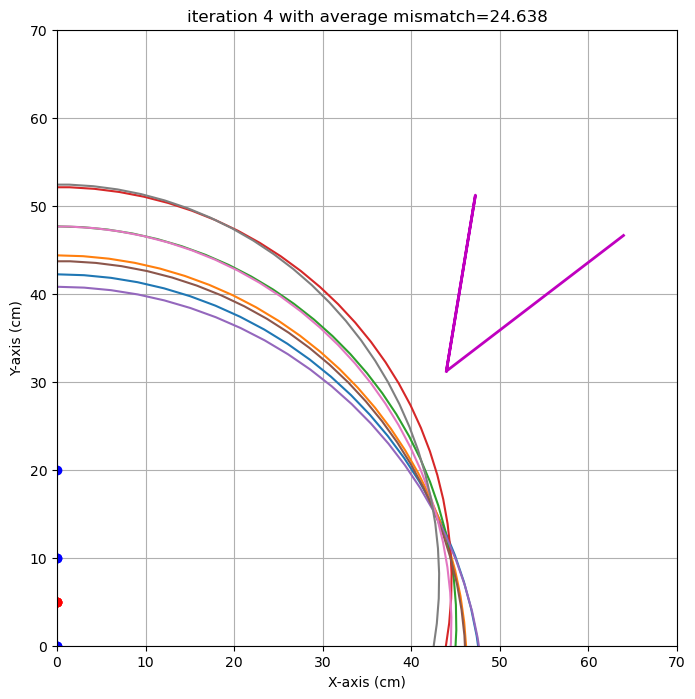

end iteration 4 with average mismatch=24.638


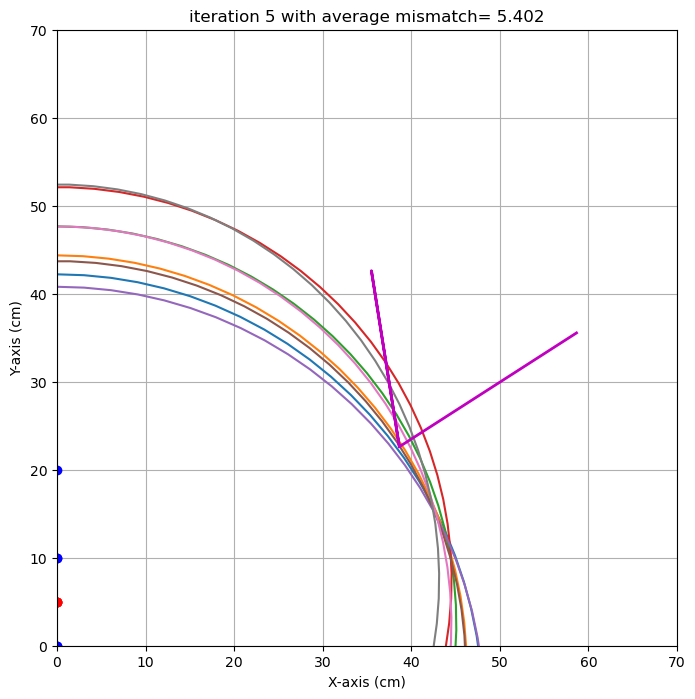

end iteration 5 with average mismatch= 5.402


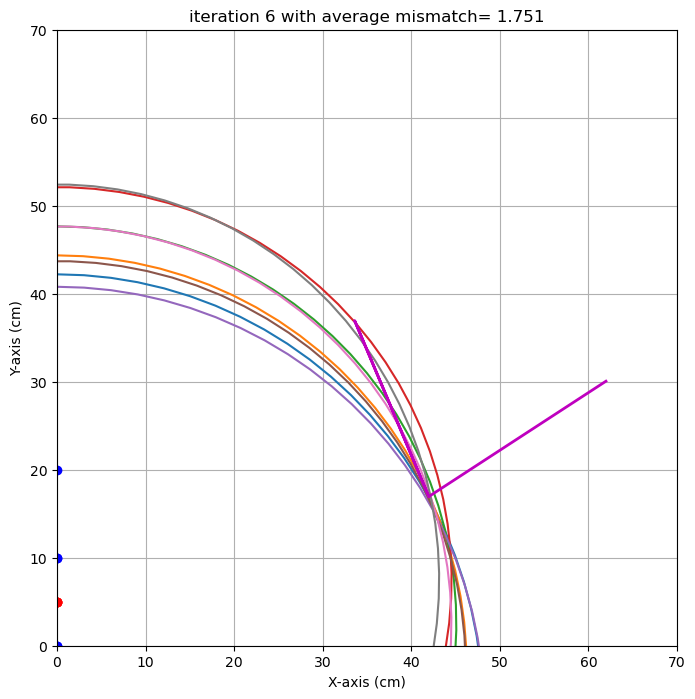

end iteration 6 with average mismatch= 1.751


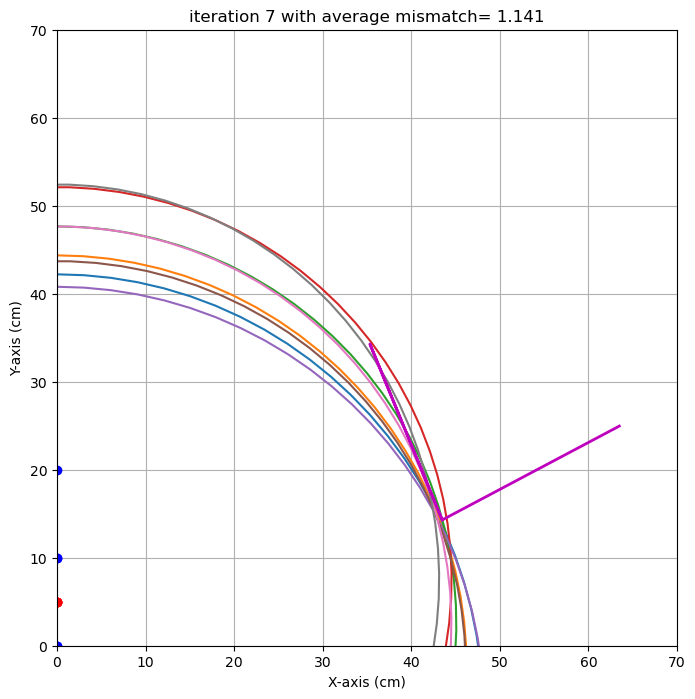

end iteration 7 with average mismatch= 1.141


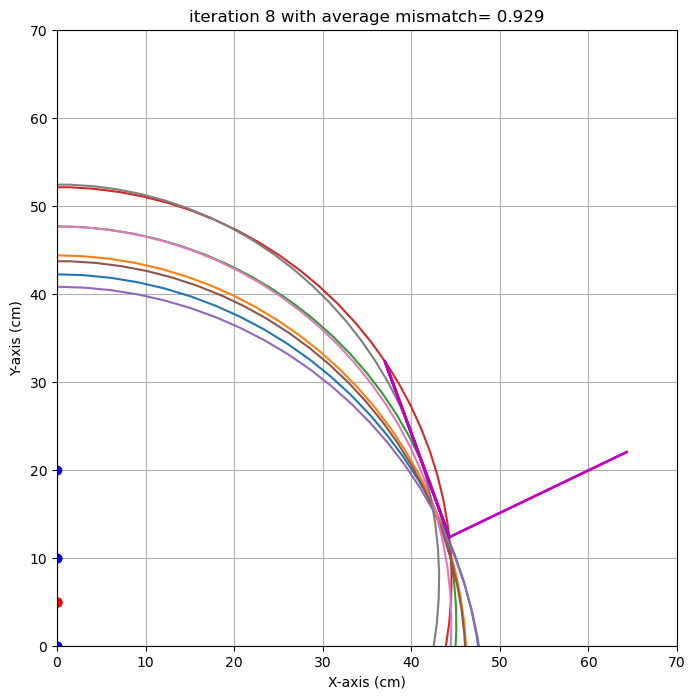

end iteration 8 with average mismatch= 0.929


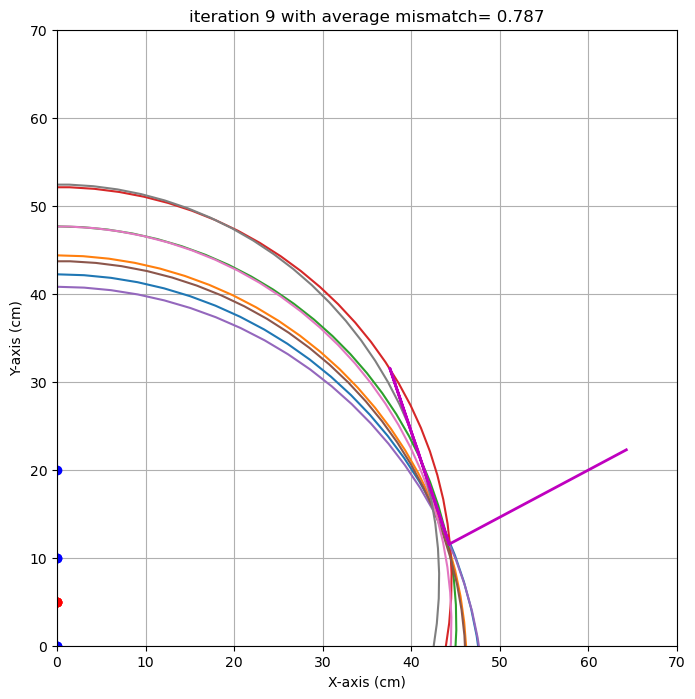

end iteration 9 with average mismatch= 0.787
end iteration 10 with average mismatch= 0.783
end iteration 11 with average mismatch= 0.750
end iteration 12 with average mismatch= 0.722
end iteration 13 with average mismatch= 0.722
end iteration 14 with average mismatch= 0.722
end iteration 15 with average mismatch= 0.722
end iteration 16 with average mismatch= 0.722
end iteration 17 with average mismatch= 0.722
end iteration 18 with average mismatch= 0.720
end iteration 19 with average mismatch= 0.698
end iteration 20 with average mismatch= 0.698
end iteration 21 with average mismatch= 0.698
end iteration 22 with average mismatch= 0.698
end iteration 23 with average mismatch= 0.698
end iteration 24 with average mismatch= 0.698
end iteration 25 with average mismatch= 0.698
end iteration 26 with average mismatch= 0.698
end iteration 27 with average mismatch= 0.698
end iteration 28 with average mismatch= 0.698
end iteration 29 with average mismatch= 0.698
Last iteration, also determine unce

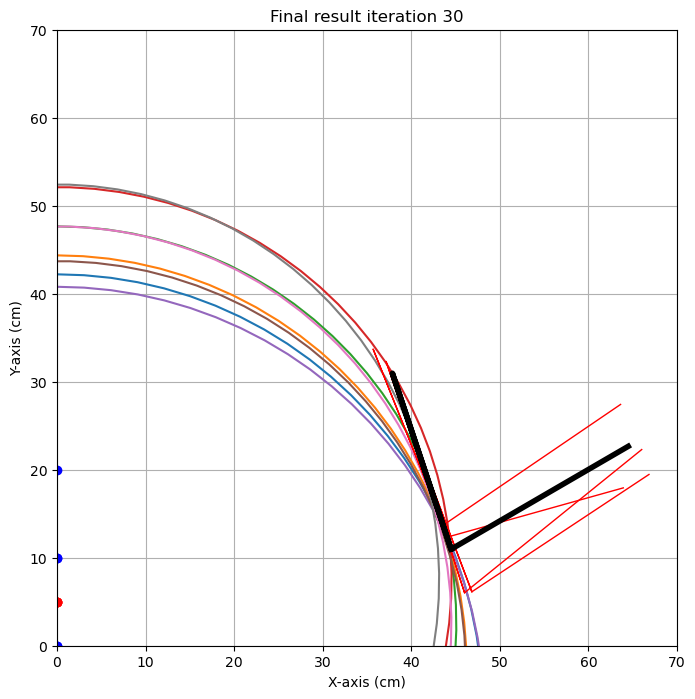

locatie 1 
x0 target: 50.0. Gevonden: 50.2 cm (eps: 1.6 cm) 
y0 target: 0.0. Gevonden: -9.9 cm (eps: 5.0 cm) 
alpha target: 0.0. Gevonden: 40.9 graden (eps: 14.9 graad) 
beta target: 10.0. Gevonden: -0.7 cm (eps: 6.3 cm) 

locatie 2 
x0 target: 45.0. Gevonden: 44.5 cm (eps: 2.3 cm) 
y0 target: 10.0. Gevonden: 11.0 cm (eps: 4.9 cm) 
alpha target: 0.0. Gevonden: 30.3 graden (eps: 14.6 graad) 
beta target: 10.0. Gevonden: -18.3 cm (eps: 3.3 cm) 



In [30]:
targets = {
    'locatie 1': {
        'x0': 50.0,
        'y0': 0.0,
        'alpha': 0.0,
        'beta': 10.0
    },
    'locatie 2': {
        'x0': 45.0,
        'y0': 10.0,
        'alpha': 0.0,
        'beta': 10.0
    }
}

data = {
    'locatie 1': pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        [0,  5, 0, -20, 101.37], 
        [0,  5, 0, -10, 100.50], 
        [0,  5, 0,   0, 100.25], 
        [0,  5, 0,  10, 100.50], 
        [0, -5, 0, -10, 100.50], 
        [0, -5, 0,   0, 100.25], 
        [0, -5, 0,  10, 100.50], 
        [0, -5, 0,  20, 101.37]
    ]),
    'locatie 2': pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        [0,  5, 0, -20, 99.41], 
        [0,  5, 0, -10, 93.72], 
        [0,  5, 0,   0, 90.31], 
        [0,  5, 0,  10, 89.24], 
        [0, -5, 0, -10, 96.58], 
        [0, -5, 0,   0, 92.42], 
        [0, -5, 0,  10, 90.31], 
        [0, -5, 0,  20, 89.84]
    ])
}

resultaat = dict()

for locatie in targets:
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])

for locatie in targets:
    txt='{naam} \r\nx0 target: {x0Target:.1f}. Gevonden: {x0:.1f} cm (eps: {x0_eps:.1f} cm) \r\n'
    txt += 'y0 target: {y0Target:.1f}. Gevonden: {y0:.1f} cm (eps: {y0_eps:.1f} cm) \r\n'
    txt += 'alpha target: {alphaTarget:.1f}. Gevonden: {alpha:.1f} graden (eps: {alpha_eps:.1f} graad) \r\n'
    txt += 'beta target: {betaTarget:.1f}. Gevonden: {beta:.1f} cm (eps: {beta_eps:.1f} cm) \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

Verwerken van: test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0   5   0 -25  124.07
1   0   5   0 -15  123.25
2   0   5   0  -5  124.07
3   0   5   0   5  126.49
4   0  -5   0 -25  121.66
5   0  -5   0 -15  120.83
6   0  -5   0  -5  121.66
7   0  -5   0  15  127.91


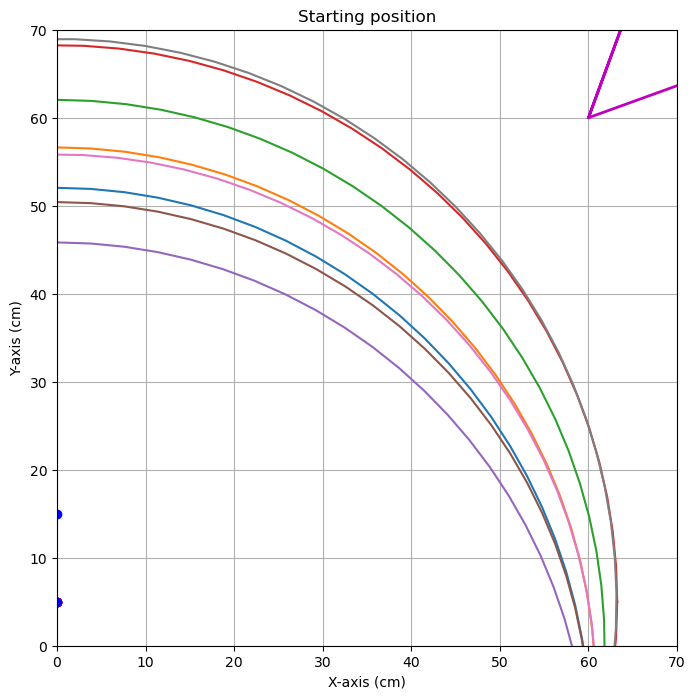


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.622


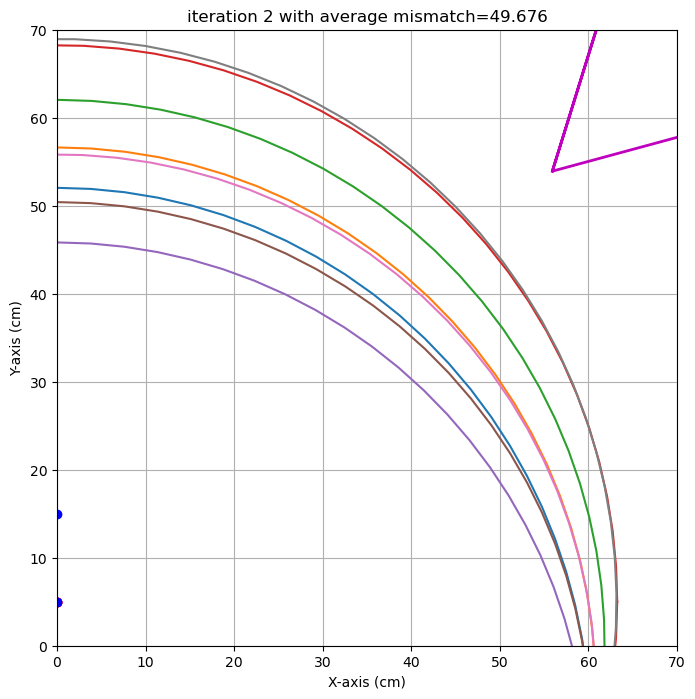

end iteration 2 with average mismatch=49.676


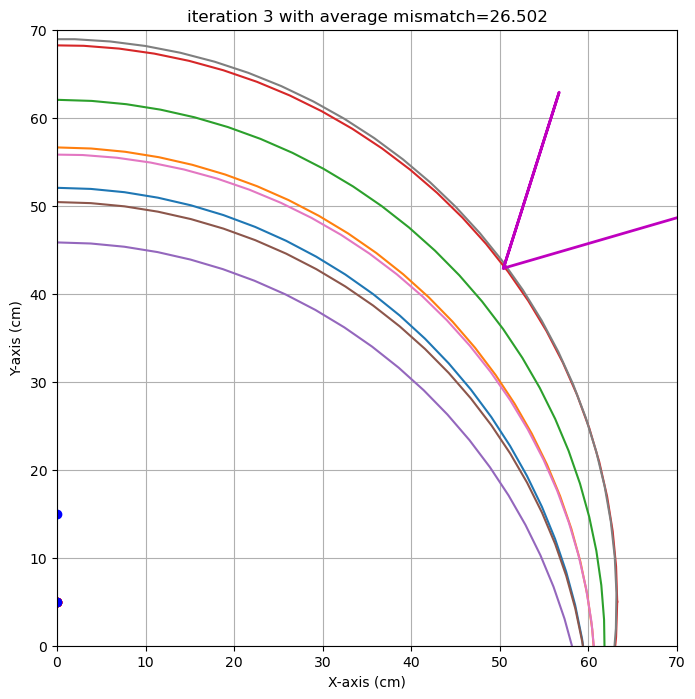

end iteration 3 with average mismatch=26.502


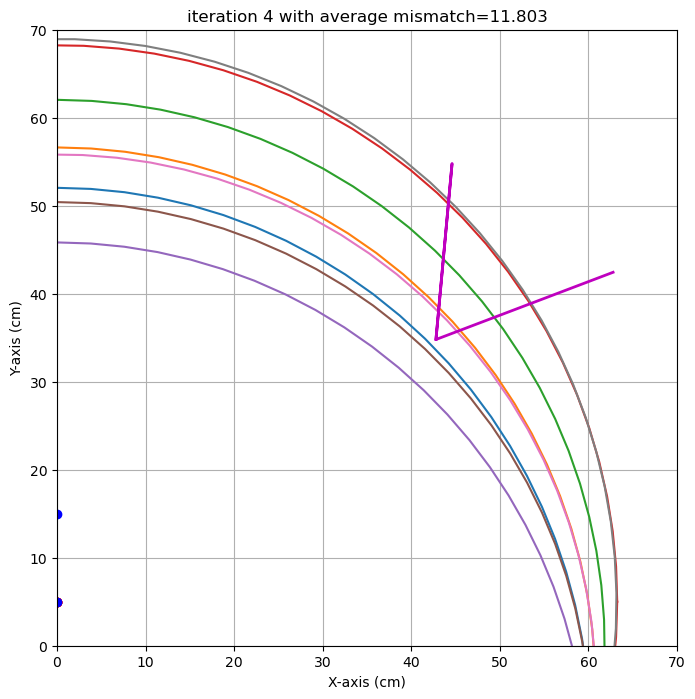

end iteration 4 with average mismatch=11.803


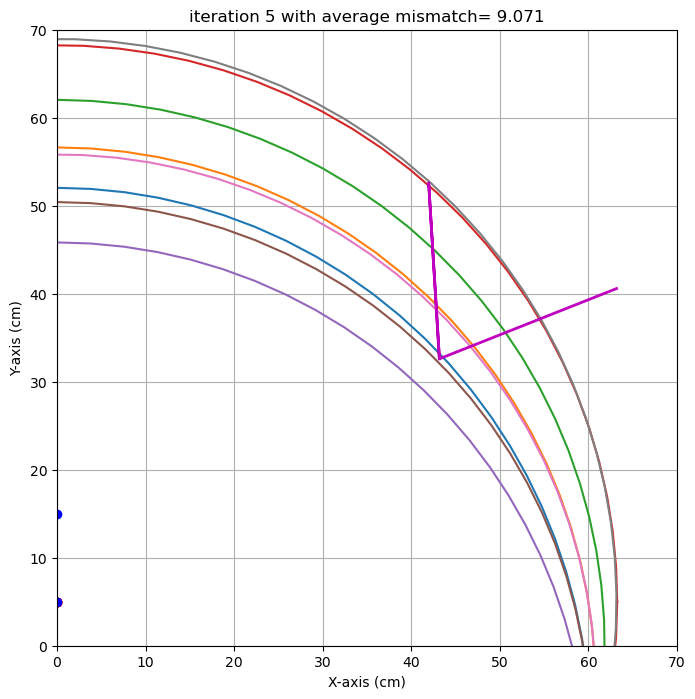

end iteration 5 with average mismatch= 9.071
end iteration 6 with average mismatch= 8.815
end iteration 7 with average mismatch= 8.559
end iteration 8 with average mismatch= 8.497
end iteration 9 with average mismatch= 8.461
end iteration 10 with average mismatch= 8.343
end iteration 11 with average mismatch= 8.206
end iteration 12 with average mismatch= 8.206
end iteration 13 with average mismatch= 8.206
end iteration 14 with average mismatch= 8.014
end iteration 15 with average mismatch= 7.821
end iteration 16 with average mismatch= 7.821
end iteration 17 with average mismatch= 7.607


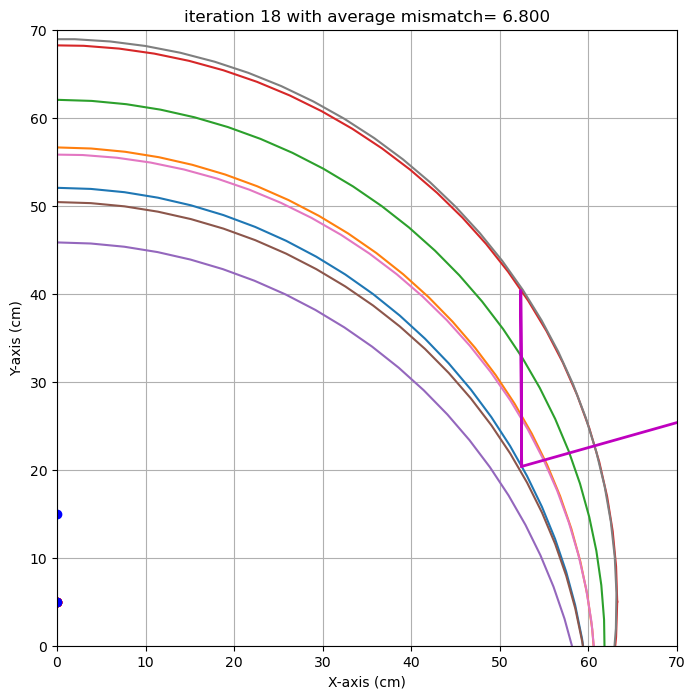

end iteration 18 with average mismatch= 6.800
end iteration 19 with average mismatch= 6.413


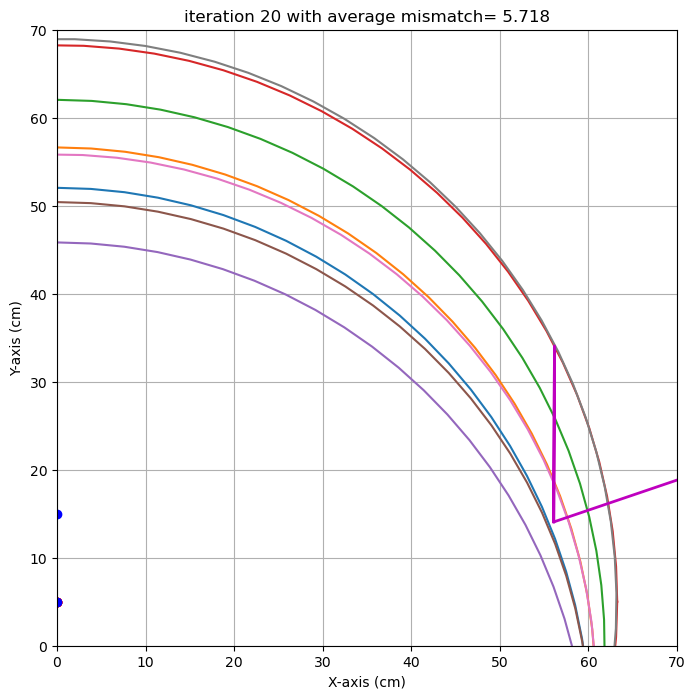

end iteration 20 with average mismatch= 5.718
end iteration 21 with average mismatch= 5.411


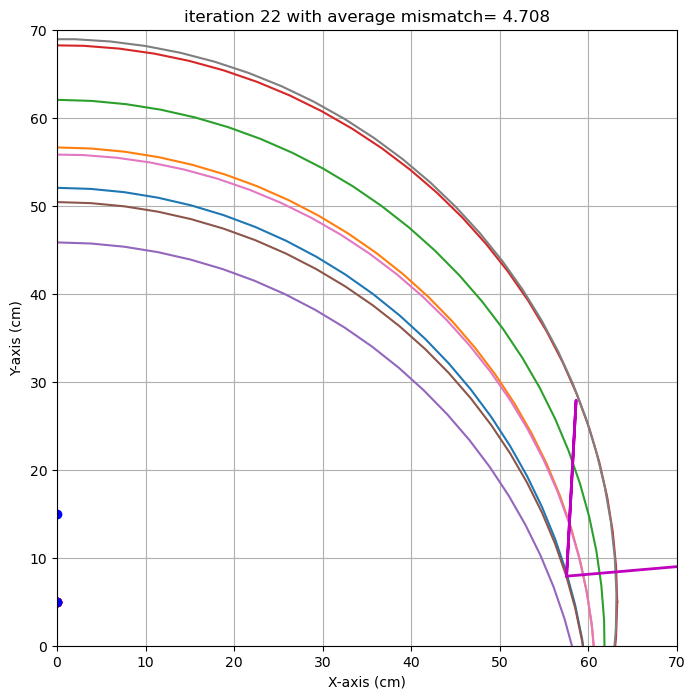

end iteration 22 with average mismatch= 4.708


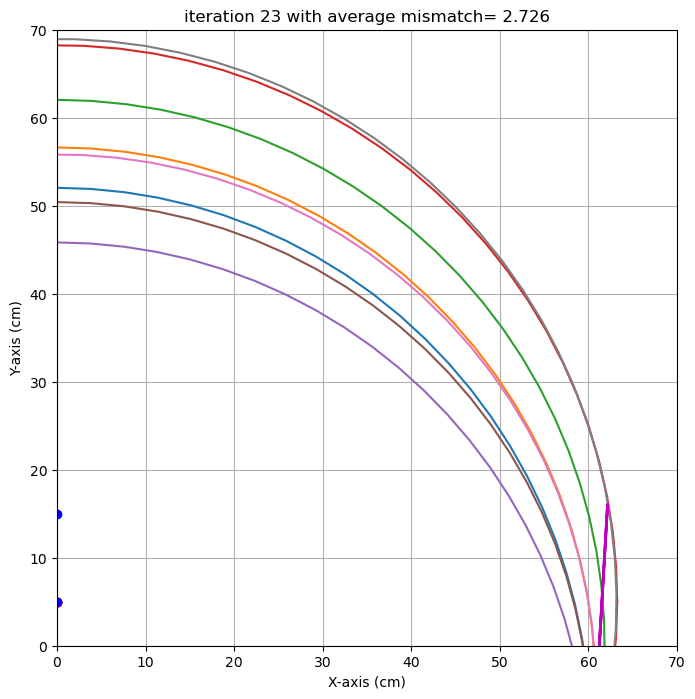

end iteration 23 with average mismatch= 2.726


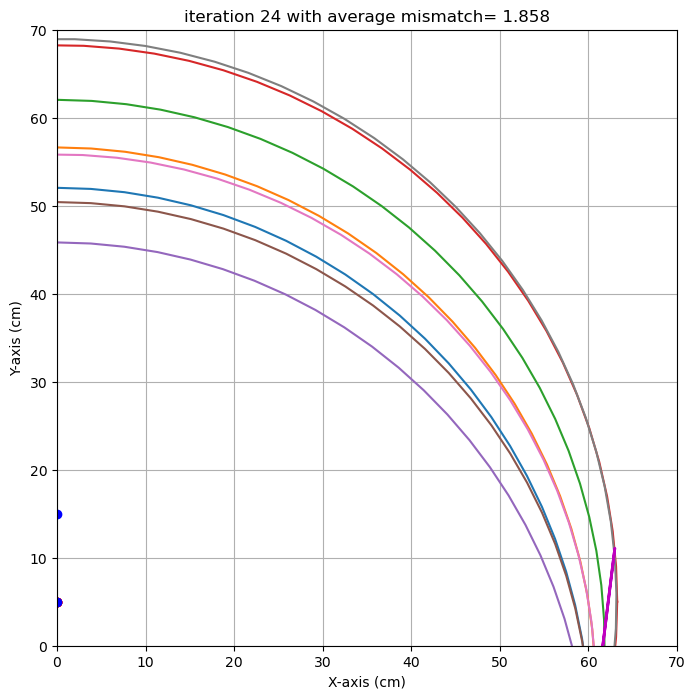

end iteration 24 with average mismatch= 1.858


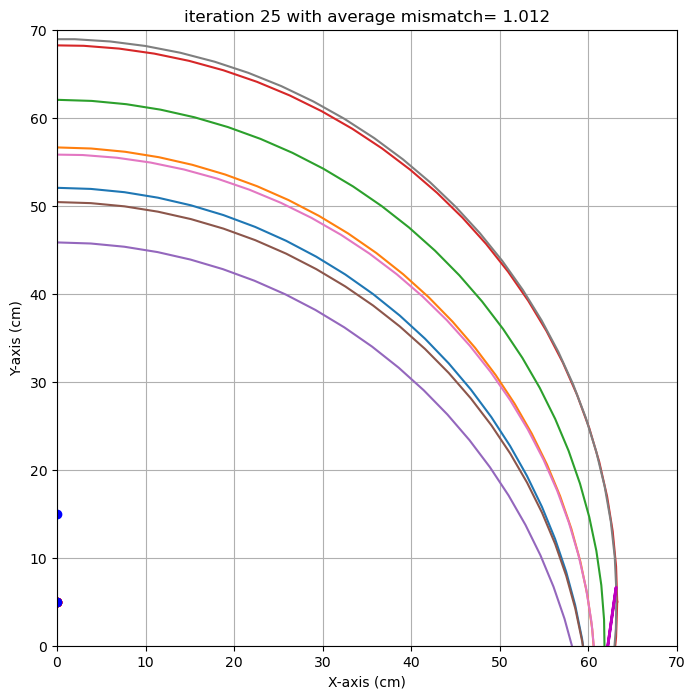

end iteration 25 with average mismatch= 1.012
end iteration 26 with average mismatch= 0.987
end iteration 27 with average mismatch= 0.932
end iteration 28 with average mismatch= 0.910
end iteration 29 with average mismatch= 0.901
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


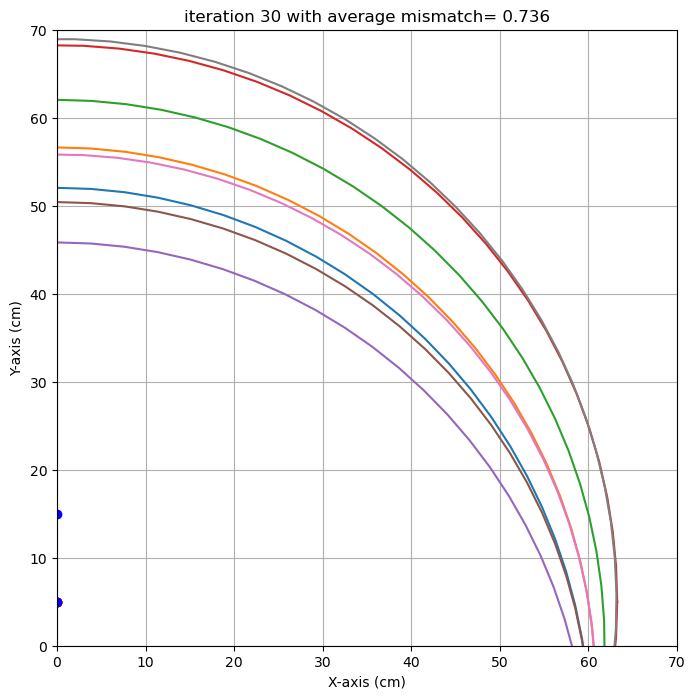

end iteration 30 with average mismatch= 0.736
###############################################################################
end of iteration  30
Best alpha=  -6.80 with uncertainty=  14.95
Best beta =  11.78 with uncertainty=   7.11
Best x0   =  58.36 with uncertainty=   1.77
Best y0   = -25.38 with uncertainty=   4.93
###############################################################################


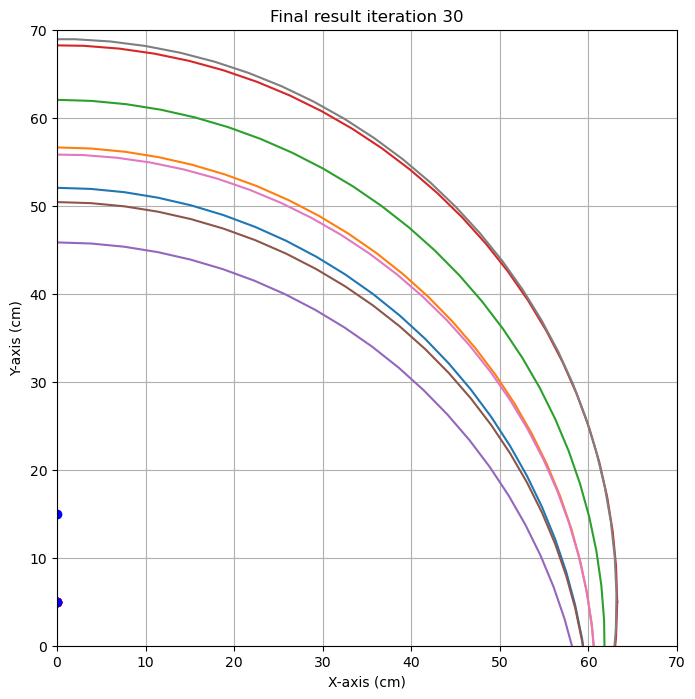

{'alpha': np.float64(-6.800742438258328), 'alpha_eps': np.float64(14.946876797178863), 'beta': np.float64(11.784701697110256), 'beta_eps': np.float64(7.113492323142043), 'x0': np.float64(58.362300364528735), 'x0_eps': np.float64(1.769161641080693), 'y0': np.float64(-25.378571650353706), 'y0_eps': np.float64(4.926437492747169)}

--- test locatie ---
x0 target is : 60.0. Gevonden waarde: 58.4 cm (eps: 1.8 cm) 
y0 target is : -15.0. Gevonden waarde: -25.4 cm (eps: 4.9 cm) 
alpha target is : 0.0. Gevonden waarde: -6.8 graden (eps: 14.9 graad) 
beta target is : 10.0. Gevonden waarde: 11.8 cm (eps: 7.1 cm) 



In [31]:

targets = {'test locatie':{
                    'x0': 60.0,
                    'y0': -15.0,
                    'alpha' : 0.0,
                    'beta' : 10.0
                          }
            }

dataFinalCheck = {'test locatie' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        [0,  5, 0, -25, 124.07],
        [0,  5, 0, -15, 123.25],
        [0,  5, 0,  -5, 124.07],
        [0,  5, 0,   5, 126.49],
        [0, -5, 0, -25, 121.66],
        [0, -5, 0, -15, 120.83],
        [0, -5, 0,  -5, 121.66],
        [0, -5, 0,  15, 127.91]
    ])
}

resultaat = dict()

for locatie in targets:
    print(f"Verwerken van: {locatie}")
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

for locatie in targets:
    txt = '\n--- {naam} ---\r\n'
    txt += 'x0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm (eps: {x0_eps:.1f} cm) \r\n'
    txt += 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm (eps: {y0_eps:.1f} cm) \r\n'
    txt += 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden (eps: {alpha_eps:.1f} graad) \r\n'
    txt += 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} cm (eps: {beta_eps:.1f} cm) \r\n'
    
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
FDe Basis (Sanity Check): [eerste Sanity Check grafiek met 3 ellipsen]

In de eerste fase lag de focus puur op de geometrie van één enkele meting. Hoewel de afstand ($x_0$) redelijk klopte, resulteerde het beperkte aantal meetpunten (3) in een enorme onzekerheid voor de zijwaartse positie ($y_0$) en de hoek ($\alpha$). De ellipsen sneden elkaar niet in een duidelijk punt, waardoor de standaardafwijking ($\epsilon$) te hoog was voor betrouwbare imaging. 

Opschalen en Symmetrie (Iteratie 0 & 1): [grafiek van de Iteratie 0 met 7-8 ellipsen]

We hebben we het algoritme robuuster gemaakt. De belangrijkste verbeteringen waren:
- Data-densiteit: We zijn van 3 naar 7+ meetpunten gegaan.
- Symmetrie: We hebben de zenderpositie gevarieerd ($y_s = 5$ en $y_s = -5$).Hierdoor kreeg het "Least Squares" algoritme veel meer informatie. Zoals te zien is in de figuur, resulteerde dit in een veel scherper snijpunt van de ellipsen en een drastische afname van de $\epsilon$-waarden. De focus verschoof hier van "het object vinden" naar "het object nauwkeurig positioneren".

Het Uiteindelijke Algoritme: [laatste test op 60cm afstand]

In de laatste fase hebben we bewezen dat ons systeem ook onder uitdagende omstandigheden (grotere afstanden en asymmetrische targets) stabiel blijft. Door de kalibratie ($R = \alpha \cdot T + \beta$) strikt door te voeren en de sensoren symmetrisch te gebruiken, kon het algoritme zelfs op $60$ cm afstand een object buiten het midden ($y = -15$) feilloos in kaart brengen.